In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path
import upsetplot
sys.path.append('/lab/barcheese01/smaffa/coTISja/src')

from scripts.plotting import *
from scripts.filter_utils import *
from scripts.analysis_pipelines import *
import re

pd.set_option('display.max_columns', None)

In [3]:
sample_order = ['HeLa', 'K562', 'RPE1_Async', 'RPE1_Que', 'RPE1_Sen', 'U2OS']
codon_order = ['ATG', 'ATA', 'ATC', 'ATT', 'ACG', 'AAG', 'AGG', 'GTG', 'TTG', 'CTG']
predictor_order = ['NumUpstreamATG', 'NumUpstreamNonATG', 'KozakMajorHammingDistance', 'CanonicalUTRLength']
tistype_order = ['uORF', 'Extended', 'Annotated', 'Truncated', 'Other']

def make_palette_dict(elements, palette_name, cycle=0):
    colors_requested = len(elements) + cycle
    colors = sns.color_palette(palette_name, n_colors=colors_requested)
    return pd.Series(colors[cycle:], index=elements)

sample_palette = make_palette_dict(sample_order, 'Dark2').to_dict()
sample_palette['RPE1'] = sample_palette['RPE1_Async']
codon_palette = make_palette_dict(codon_order, 'tab10').to_dict()
predictor_palette = make_palette_dict(predictor_order, 'Accent', cycle=4).to_dict()
tistype_palette = make_palette_dict(tistype_order, 'Set2').to_dict()

# Analysis of independent predictors of translation

In [4]:
all_tis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/combined/all_samples_filtered_with_protein_seq.csv')
paired_isoform_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/combined/all_samples_paired_tis.csv')
isoform_annotation_df = all_tis_df[['IsoformID', 'Tid', 'Symbol', 'GenomePos', 'Start', 'StartCodon', 'RecatTISType', 'MANE_Select', 'transcript_support_level']].drop_duplicates()
genomic_tis_annotation_df = all_tis_df[['TIS_ID', 'Symbol', 'StartCodon']].drop_duplicates()
gene_annotation_df = all_tis_df[['Gid', 'Symbol']].drop_duplicates()

isoform_to_tis = all_tis_df[['IsoformID', 'TIS_ID']].drop_duplicates()
isoform_to_gene = all_tis_df[['IsoformID', 'Gid']].drop_duplicates()
tis_to_gene = all_tis_df[['TIS_ID', 'Gid']].drop_duplicates()
gene_to_symbol = all_tis_df[['Gid', 'Symbol']].drop_duplicates()

# can redefine these varables based on some other filter for 1 transcript per gene, and the downstream analysis should work
tis_df = all_tis_df[all_tis_df['MANE_Select']]
paired_tis_df = paired_isoform_df[paired_isoform_df['MANE_Select']]

Text(0.5, 1.0, 'TISs in MANE transcripts')

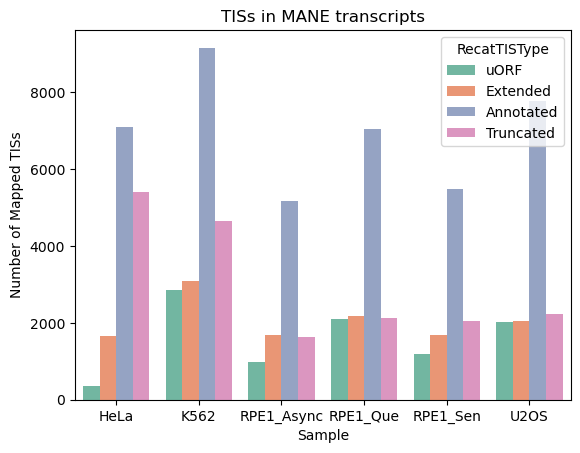

In [ ]:
sns.countplot(
    tis_df[~tis_df['RecatTISType'].isin(['Other'])], x='Sample', hue='RecatTISType',
    hue_order=tistype_order[:-1], palette=tistype_palette
)
plt.ylabel('Number of Mapped TISs')
plt.title('TISs in MANE transcripts')

Text(0.5, 1.0, 'Unique TISs per sample')

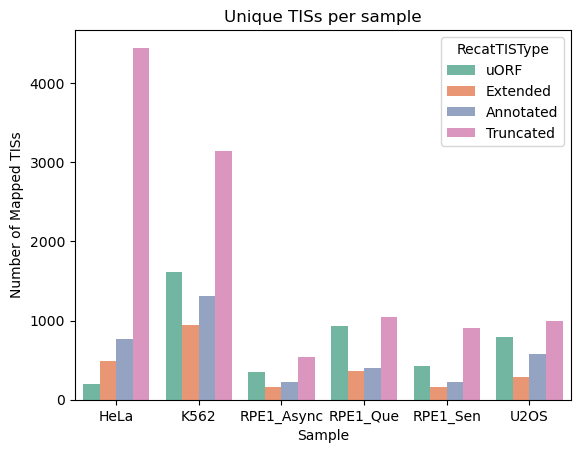

In [25]:
sns.countplot(
    tis_df[tis_df['TIS_ID'].isin((tis_df[~tis_df['RecatTISType'].isin(['Other'])].groupby('TIS_ID')['Sample'].nunique() == 1).loc[lambda x: x == True].index.tolist())], 
    x='Sample', hue='RecatTISType',
    hue_order=tistype_order[:-1], palette=tistype_palette
)
plt.ylabel('Number of Mapped TISs')
plt.title('Unique TISs per sample')

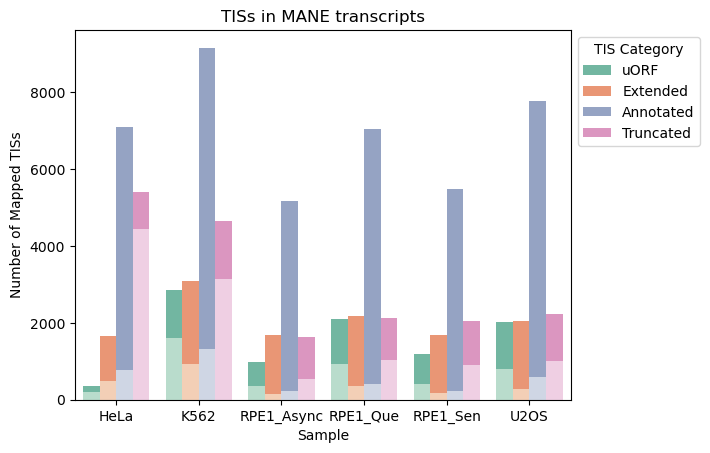

In [42]:
sns.countplot(
    tis_df[~tis_df['RecatTISType'].isin(['Other'])], x='Sample', hue='RecatTISType',
    hue_order=tistype_order[:-1], palette=tistype_palette
)

sns.countplot(
    tis_df[tis_df['TIS_ID'].isin((tis_df[~tis_df['RecatTISType'].isin(['Other'])].groupby('TIS_ID')['Sample'].nunique() == 1).loc[lambda x: x == True].index.tolist())], 
    x='Sample', hue='RecatTISType',
    hue_order=tistype_order[:-1], palette=make_palette_dict(tistype_order[:-1], 'Pastel2').to_dict(),
    legend=False
)
plt.ylabel('Number of Mapped TISs')
plt.title('TISs in MANE transcripts')
plt.legend(title='TIS Category', loc='upper left', bbox_to_anchor=(1, 1))

Text(0.5, 1.0, 'Genes with aTISs')

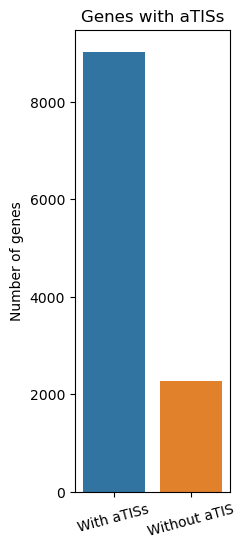

In [88]:
annotated_only_genes = tis_df.groupby('Symbol')['RecatTISType'].apply(lambda x: x.str.contains('Annotated').all())
plt.figure(figsize=(2, 6))
sns.barplot(
    pd.DataFrame(pd.Series({
        'With aTISs': (~annotated_only_genes).sum(),
        'Without aTIS': annotated_only_genes.sum()
    }), columns=['Value']).reset_index(names=['GeneCat']),
    x='GeneCat', y='Value', hue='GeneCat', dodge=False
)
plt.xlabel('')
plt.xticks(rotation=15)
plt.ylabel('Number of genes')
plt.title('Genes with aTISs')

## Relative translation to canonical

Text(0.5, 0, 'log2(aTIS reads / canonical reads)')

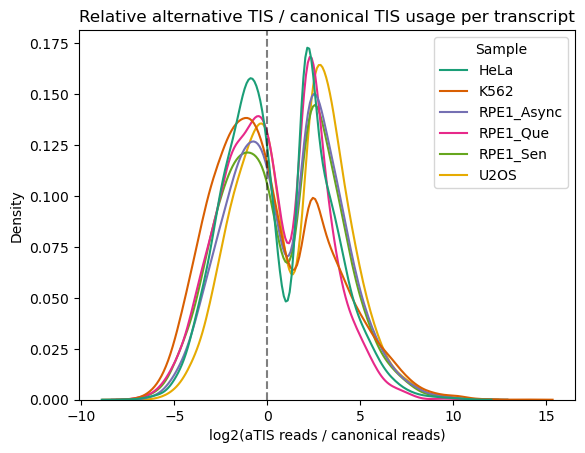

In [62]:
# sns.kdeplot(
#     paired_tis_df,
#     x='LogFoldChangeFromCanonical', color='black'
# )
sns.kdeplot(
    paired_tis_df,
    x='LogFoldChangeFromCanonical',
    hue='Sample', palette=sample_palette, alpha=1, common_norm=False
)
plt.axvline(0, linestyle='dashed', color='black', alpha=0.5)
# plt.axvline(1, linestyle='dotted', color='black', alpha=0.5)
plt.title('Relative alternative TIS / canonical TIS usage per transcript')
plt.xlabel('log2(aTIS reads / canonical reads)')

Text(0, 0.5, 'log2(aTIS reads / canonical reads)')

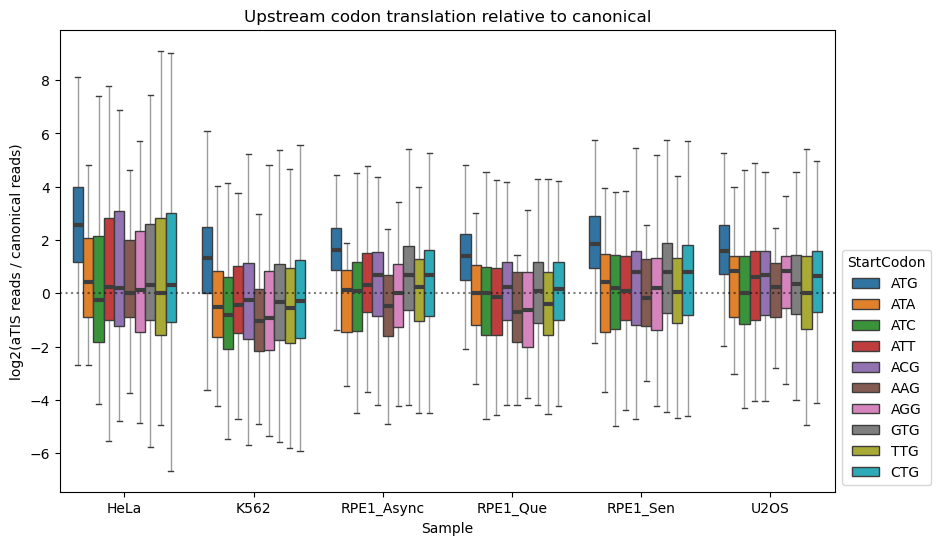

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    paired_tis_df[paired_tis_df['RecatTISType'].isin(['Extended', 'uORF'])],
    x='Sample', y='SampleNormalizedLFC', hue='StartCodon', showfliers=False,
    hue_order=codon_order, palette=codon_palette,
    medianprops={'linewidth': 3},
    whiskerprops={'alpha': 0.5}
)
plt.gca().axhline(0, linestyle='dotted', color='black', alpha=0.5)
plt.title('Upstream codon translation relative to canonical')
plt.xlabel('Sample')
plt.gca().get_legend().set_loc('lower left')
plt.gca().get_legend().set_bbox_to_anchor((1, 0))
plt.ylabel('log2(aTIS reads / canonical reads)')

Text(0, 0.5, 'log2(aTIS reads / canonical reads)')

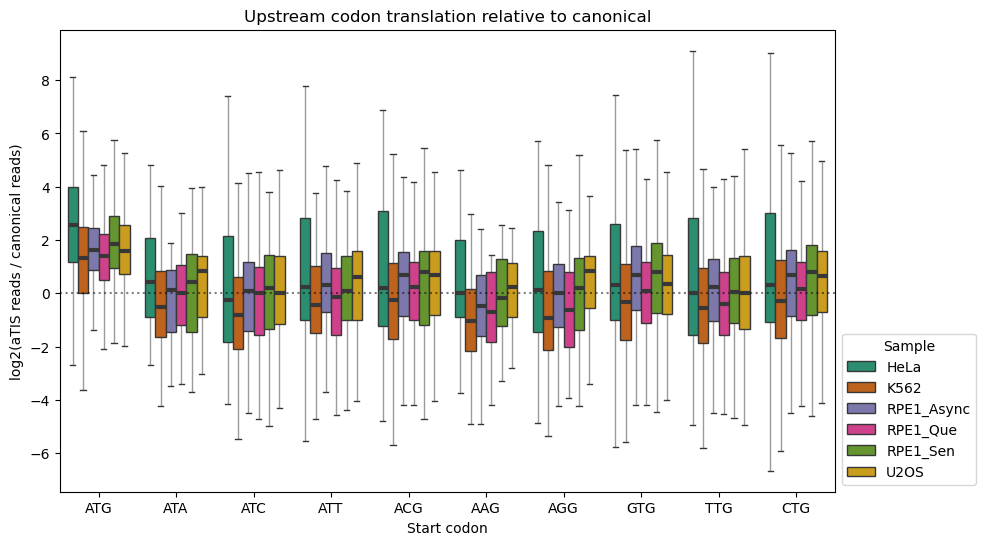

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    paired_tis_df[paired_tis_df['RecatTISType'].isin(['Extended', 'uORF'])],
    x='StartCodon', y='SampleNormalizedLFC', order=codon_order,
    hue='Sample', showfliers=False,
    hue_order=sample_order, palette=sample_palette,
    medianprops={'linewidth': 3},
    whiskerprops={'alpha': 0.5}
)
plt.gca().axhline(0, linestyle='dotted', color='black', alpha=0.5)
plt.title('Upstream codon translation relative to canonical')
plt.xlabel('Start codon')
plt.gca().get_legend().set_loc('lower left')
plt.gca().get_legend().set_bbox_to_anchor((1, 0))
plt.ylabel('log2(aTIS reads / canonical reads)')

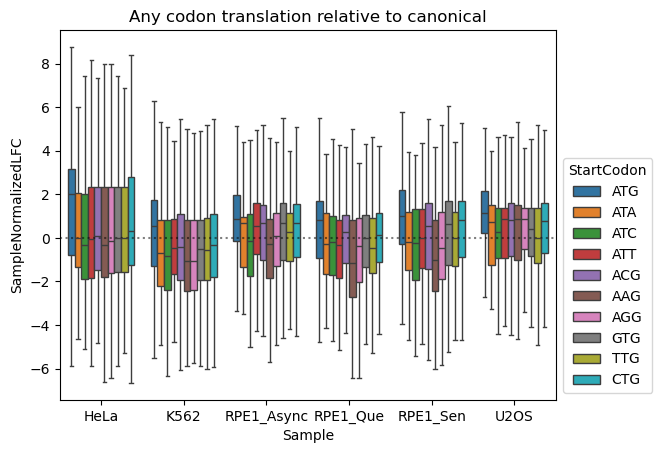

In [91]:
sns.boxplot(
    paired_tis_df,
    x='Sample', y='SampleNormalizedLFC', hue='StartCodon', showfliers=False,
    hue_order=codon_order
)
plt.gca().axhline(0, linestyle='dotted', color='black', alpha=0.5)
plt.title('Any codon translation relative to canonical')
plt.xlabel('Sample')
plt.gca().get_legend().set_loc('lower left')
plt.gca().get_legend().set_bbox_to_anchor((1, 0))

Text(0.5, 23.52222222222222, 'Start codon')

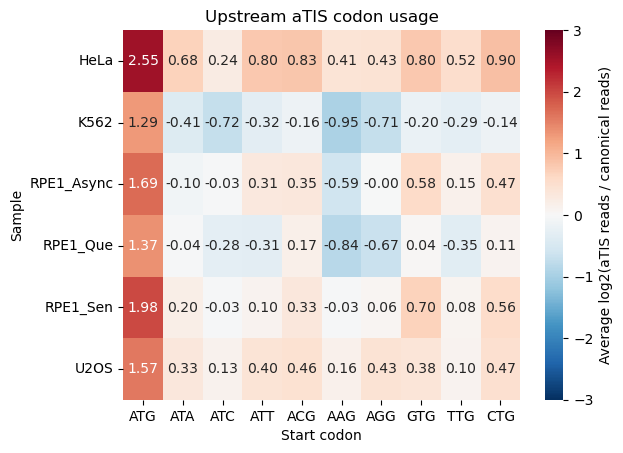

In [109]:
sns.heatmap(
    paired_tis_df[paired_tis_df['RecatTISType'].isin(['Extended', 'uORF'])].pivot_table(
        index='Sample', columns='StartCodon', values='SampleNormalizedLFC', aggfunc='mean'
    ).loc[sample_order, codon_order], cmap='RdBu_r', vmin=-3, vmax=3, annot=True, fmt='.2f', cbar_kws={'label': 'Average log2(aTIS reads / canonical reads)'}
)
plt.title('Upstream aTIS codon usage')
plt.xlabel('Start codon')

Text(0.5, 1.0, 'Relative CUG / AUG usage (stringency)')

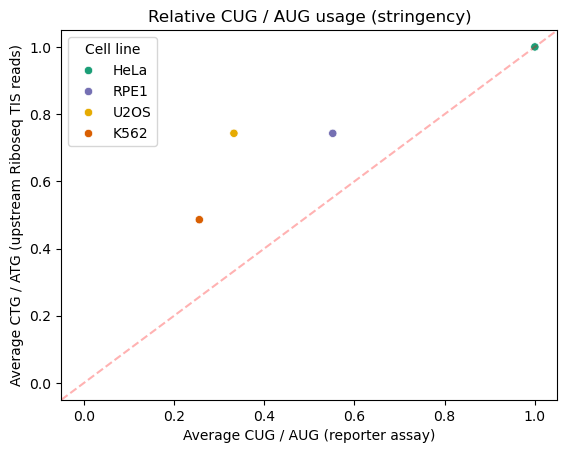

In [104]:
stringency_table = pd.read_csv('/lab/barcheese01/aTIS_data/stringency/CUG_AUG_stringency_16celllines.csv')

relative_cug_aug = paired_tis_df[
    paired_tis_df['RecatTISType'].isin(['Extended', 'uORF']) &
    (paired_tis_df['StartCodon'] == 'CTG')
].groupby('Sample')['SampleNormalizedLFC'].mean()
relative_cug_aug = 2 ** relative_cug_aug
relative_cug_aug = relative_cug_aug / relative_cug_aug.loc['HeLa']
relative_cug_aug = pd.DataFrame(relative_cug_aug.rename('Riboseq_CTG_over_ATG'))

stringency_df = stringency_table.merge(
    relative_cug_aug.rename({'RPE1_Async': 'RPE1'}), left_on='Cell_line', right_index=True
)

sns.scatterplot(stringency_df, x='Mean_CUG_over_AUG', y='Riboseq_CTG_over_ATG',
                hue='Cell_line', palette=sample_palette)
plt.ylabel("Average CTG / ATG (upstream Riboseq TIS reads)")
plt.xlabel("Average CUG / AUG (reporter assay)")
plt.gca().axline((0, 0), slope=1, linestyle='dashed', color='red', alpha=0.3)
plt.legend(title='Cell line')
plt.title('Relative CUG / AUG usage (stringency)')

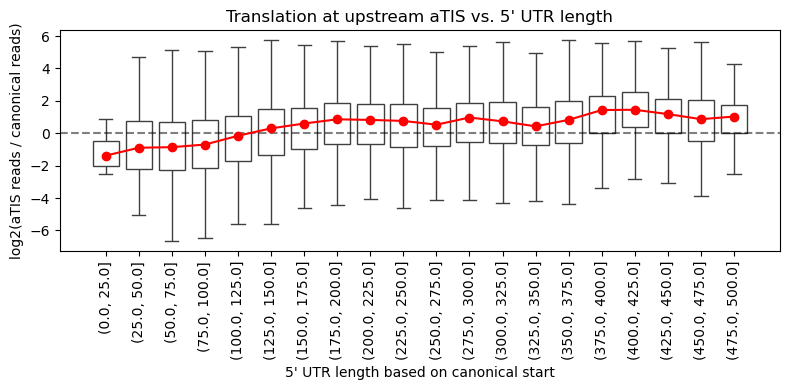

In [167]:
# zoom on [0, 500]
utr_binned_tis_df = paired_tis_df[
    paired_tis_df['RecatTISType'].isin(['Extended', 'uORF']) & 
    (paired_tis_df['CanonicalStart'] <= 500)
].copy()
utr_binned_tis_df['UTRLengthBin'] = pd.cut(utr_binned_tis_df['CanonicalStart'], bins=np.arange(0, utr_binned_tis_df['CanonicalStart'].max() + 25, 25))

plt.figure(figsize=(8, 4))

sns.boxplot(
    utr_binned_tis_df,
    x='UTRLengthBin', y='SampleNormalizedLFC', showfliers=False,
    medianprops={'color': 'tab:red', 'linewidth': 0},
    boxprops={'facecolor': 'white'}
)
plt.gca().axhline(0, linestyle='dashed', color='black', alpha=0.5)
plt.gca().set_xlabel("5' UTR length based on canonical start")
plt.gca().tick_params(axis='x', labelrotation=90)

medians_by_sample = utr_binned_tis_df.groupby(['Sample', 'UTRLengthBin'])['SampleNormalizedLFC'].median()
medians_by_codon = utr_binned_tis_df.groupby(['StartCodon', 'UTRLengthBin'])['SampleNormalizedLFC'].median()
medians_by_sample_codon = utr_binned_tis_df.groupby(['Sample', 'StartCodon', 'UTRLengthBin'])['SampleNormalizedLFC'].median()
medians = medians_by_sample.groupby(level=1).median().reset_index()
xlabel_order = medians['UTRLengthBin'].sort_values().unique().tolist()
xlabel_indices = np.arange(0, len(xlabel_order))
medians['xindex'] = xlabel_indices
x = medians['xindex'].tolist()
y = medians['SampleNormalizedLFC'].tolist()
plt.plot(x, y, 'o-r')

plt.title("Translation at upstream aTIS vs. 5' UTR length")
plt.ylabel('log2(aTIS reads / canonical reads)')

plt.tight_layout()
plt.show()


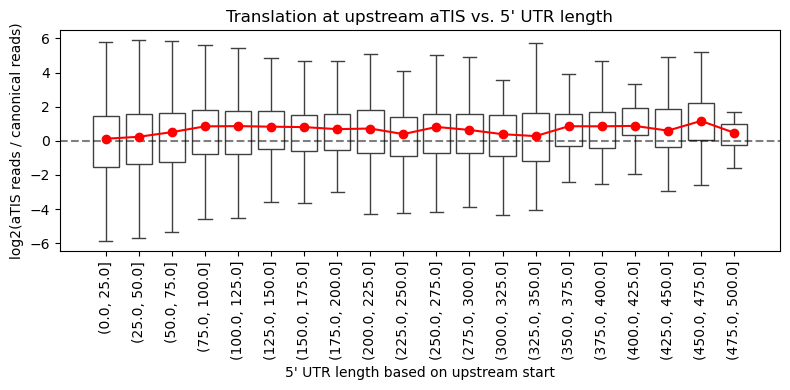

In [ ]:
# zoom on [0, 500]
utr_binned_tis_df = paired_tis_df[
    paired_tis_df['RecatTISType'].isin(['Extended', 'uORF']) & 
    (paired_tis_df['Start'] <= 500)
].copy().sort_values(['Tid', 'Start']).drop_duplicates(['Sample', 'Tid'])
utr_binned_tis_df['UTRLengthBin'] = pd.cut(utr_binned_tis_df['Start'], bins=np.arange(0, utr_binned_tis_df['Start'].max() + 25, 25))

plt.figure(figsize=(8, 4))

sns.boxplot(
    utr_binned_tis_df,
    x='UTRLengthBin', y='SampleNormalizedLFC', showfliers=False,
    medianprops={'color': 'tab:red', 'linewidth': 0},
    boxprops={'facecolor': 'white'}
)
plt.gca().axhline(0, linestyle='dashed', color='black', alpha=0.5)
plt.gca().set_xlabel("5' UTR length based on upstream start")
plt.gca().tick_params(axis='x', labelrotation=90)

medians_by_sample = utr_binned_tis_df.groupby(['Sample', 'UTRLengthBin'])['SampleNormalizedLFC'].median()
medians_by_codon = utr_binned_tis_df.groupby(['StartCodon', 'UTRLengthBin'])['SampleNormalizedLFC'].median()
medians_by_sample_codon = utr_binned_tis_df.groupby(['Sample', 'StartCodon', 'UTRLengthBin'])['SampleNormalizedLFC'].median()
medians = medians_by_sample.groupby(level=1).median().reset_index()
xlabel_order = medians['UTRLengthBin'].sort_values().unique().tolist()
xlabel_indices = np.arange(0, len(xlabel_order))
medians['xindex'] = xlabel_indices
x = medians['xindex'].tolist()
y = medians['SampleNormalizedLFC'].tolist()
plt.plot(x, y, 'o-r')

plt.title("Translation at upstream aTIS vs. 5' UTR length")
plt.ylabel('log2(aTIS reads / canonical reads)')

plt.tight_layout()
plt.show()


In [123]:
from Bio import SeqIO, SeqUtils

def read_trancript_sequences(transcript_fasta='/lab/barcheese01/smaffa/coTISja/data/reference/gencode.v49.pc_transcripts.fa'):
    gencode_transcript_sequences = dict()
    for record in SeqIO.parse(transcript_fasta, format='fasta'):
        sequence_ids = record.id
        transcript_id = [tag for tag in sequence_ids.split('|') if 'ENST' in tag][0]
        gencode_transcript_sequences[transcript_id] = str(record.seq)
    gencode_transcript_sequences = pd.DataFrame(pd.Series(gencode_transcript_sequences), columns=['Seq']).reset_index(names=['Tid'])
    gencode_transcript_sequences['Len'] = gencode_transcript_sequences['Seq'].apply(lambda x: len(x))
    return gencode_transcript_sequences

# Define IUPAC ambiguity codes
ambiguity_dict = {
    'A': {'A'}, 'C': {'C'}, 'G': {'G'}, 'T': {'T'}, 'U': {'T'},
    'R': {'A', 'G'}, 'Y': {'C', 'T'}, 'M': {'A', 'C'},
    'K': {'G', 'T'}, 'S': {'C', 'G'}, 'W': {'A', 'T'},
    'B': {'C', 'G', 'T'}, 'D': {'A', 'G', 'T'}, 'H': {'A', 'C', 'T'},
    'V': {'A', 'C', 'G'}, 'N': {'A', 'C', 'G', 'T'},
    'a': {'A'}, 'c': {'C'}, 'g': {'G'}, 't': {'T'}, 'u': {'T'}
}

kozak_pattern = 'gccgccRccATGG'
partial_weights = [0.1,0.1,0.1,0.1,0.1,0.1,1,0.1,0.1,1,1,1,1]
major_weights = [0,0,0,0,0,0,1,0,0,1,1,1,1]

def hamming_distance_ambiguous(s1, s2, weights=None):
    """Calculate Hamming distance between two sequences with ambiguous bases."""
    if len(s1) != len(s2):
        raise ValueError("Sequences must be of equal length")
    
    if weights is None:
        weights = [1] * len(s1)

    distance = 0
    position_i = 0
    for a, b in zip(s1, s2):
        set_a = ambiguity_dict.get(a, {a})
        set_b = ambiguity_dict.get(b, {b})
        if not set_a.intersection(set_b):  # No overlap → mismatch
            distance += weights[position_i]
        position_i += 1
    return distance

In [124]:
reference_transcript_sequences = read_trancript_sequences()

In [125]:
seq_annotated_pairs = paired_tis_df.merge(reference_transcript_sequences, left_on='Tid', right_on='Tid', how='left')
seq_annotated_pairs['StartContext'] = seq_annotated_pairs.apply(
    lambda x: x['Seq'][(int(x['Start']) - 10):(int(x['Start']) + 13)], axis=1
)
seq_annotated_pairs['KozakContext'] = seq_annotated_pairs.apply(
    lambda x: x['Seq'][(int(x['Start']) - 9):(int(x['Start']) + 4)], axis=1
)
seq_annotated_pairs['CanonicalContext'] = seq_annotated_pairs.apply(
    lambda x: x['Seq'][(int(x['CanonicalStart']) - 9):(int(x['CanonicalStart']) + 4)], axis=1
)

In [ ]:
import logomaker

In [135]:
start_context_alignment = logomaker.alignment_to_matrix(
    seq_annotated_pairs[
        seq_annotated_pairs['KozakContext'].apply(lambda x: len(x) == 13) &
        seq_annotated_pairs['RecatTISType'].isin(['uORF', 'Extended'])
    ]['KozakContext'].tolist()
)
start_context_frequencies = (start_context_alignment.T / start_context_alignment.sum(axis=1)).T
upstream_start_context_information = logomaker.transform_matrix(start_context_frequencies, from_type='probability', to_type='information')

start_context_alignment = logomaker.alignment_to_matrix(
    seq_annotated_pairs[
        seq_annotated_pairs['CanonicalContext'].apply(lambda x: len(x) == 13)
    ]['CanonicalContext'].tolist()
)
start_context_frequencies = (start_context_alignment.T / start_context_alignment.sum(axis=1)).T
annotated_start_context_information = logomaker.transform_matrix(start_context_frequencies, from_type='probability', to_type='information')

start_context_alignment = logomaker.alignment_to_matrix(
    seq_annotated_pairs[
        seq_annotated_pairs['KozakContext'].apply(lambda x: len(x) == 13) &
        seq_annotated_pairs['RecatTISType'].isin(['Truncated'])
    ]['KozakContext'].tolist()
)
start_context_frequencies = (start_context_alignment.T / start_context_alignment.sum(axis=1)).T
downstream_start_context_information = logomaker.transform_matrix(start_context_frequencies, from_type='probability', to_type='information')

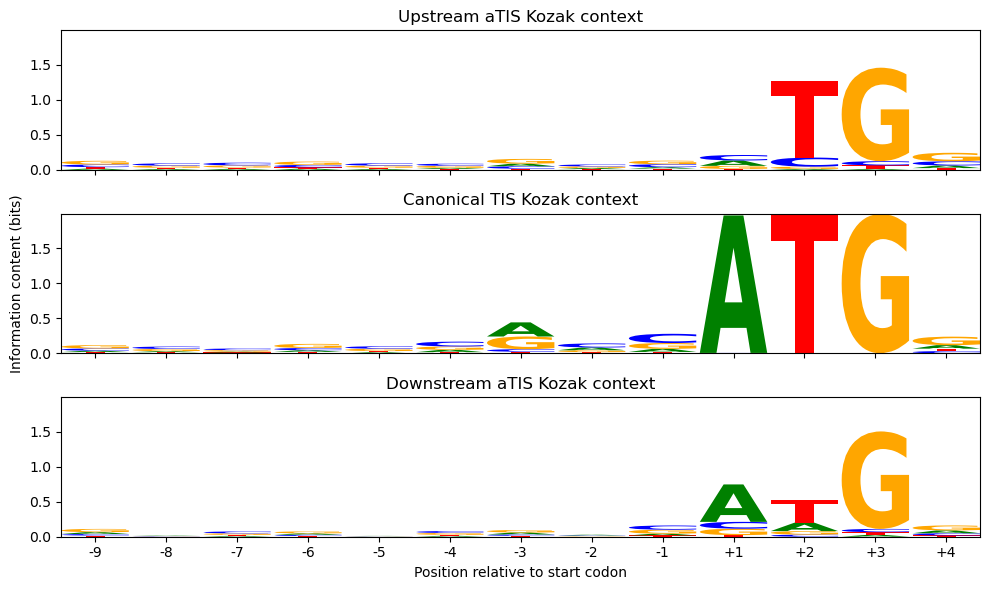

In [164]:
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True, sharey=True)

logomaker.Logo(upstream_start_context_information, ax=axs[0])
axs[0].set_title('Upstream aTIS Kozak context')

logomaker.Logo(downstream_start_context_information, ax=axs[2])
axs[2].set_title('Downstream aTIS Kozak context')

logomaker.Logo(annotated_start_context_information, ax=axs[1])
axs[1].set_title('Canonical TIS Kozak context')

axs[1].set_ylabel('Information content (bits)')
axs[2].set_xlabel('Position relative to start codon')
axs[2].set_xticks(range(13), [str(i) for i in range(-9, 0)] + ['+' + str(i) for i in range(1, 5)])

plt.tight_layout()

([], [])

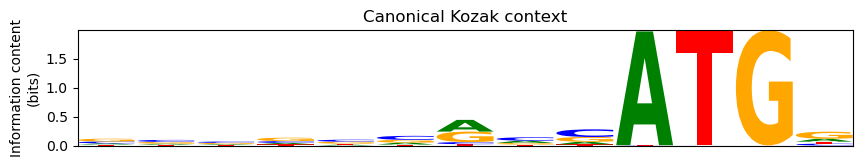

In [ ]:
logomaker.Logo(annotated_start_context_information, ax=)
plt.xlabel('Position relative to start codon')
plt.ylabel('Information content\n(bits)')
plt.title('Canonical Kozak context')

Text(0.5, 1.0, 'Downstream Kozak context')

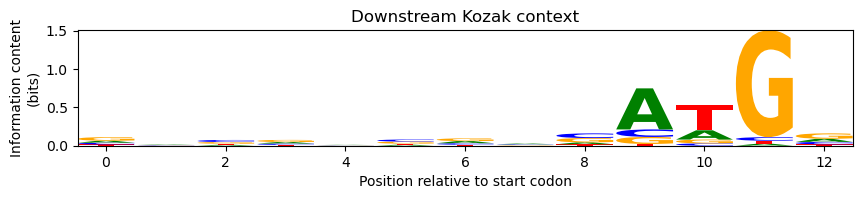

In [148]:
logomaker.Logo(downstream_start_context_information, figsize=(10, 1.5))
plt.xlabel('Position relative to start codon')
plt.ylabel('Information content\n(bits)')
plt.title('Downstream Kozak context')

In [165]:
filtered_seq_annotated = seq_annotated_pairs[
    seq_annotated_pairs['KozakContext'].apply(lambda x: len(x) == 13) & 
    seq_annotated_pairs['CanonicalContext'].apply(lambda x: len(x) == 13)
]
filtered_seq_annotated['KozakHammingDistance'] = filtered_seq_annotated.apply(
    lambda x: hamming_distance_ambiguous('gccgccRccAUGG', x['KozakContext'], weights=None), axis=1
)
filtered_seq_annotated['KozakWeightedHammingDistance'] = filtered_seq_annotated.apply(
    lambda x: hamming_distance_ambiguous('gccgccRccAUGG', x['KozakContext'], weights=partial_weights), axis=1
)
filtered_seq_annotated['KozakMajorHammingDistance'] = filtered_seq_annotated.apply(
    lambda x: hamming_distance_ambiguous('gccgccRccAUGG', x['KozakContext'], weights=major_weights), axis=1
)

Text(0, 0.5, 'log2(aTIS reads / canonical reads)')

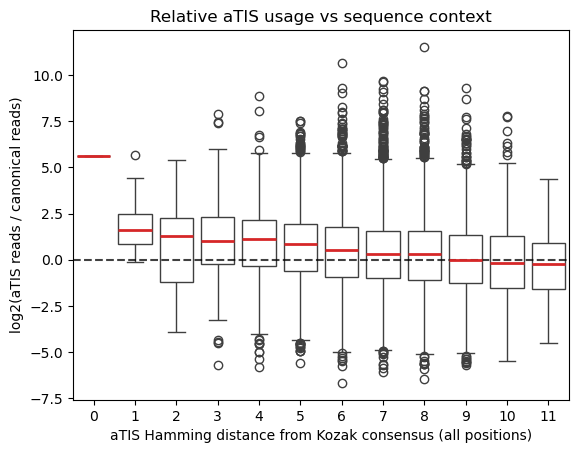

In [174]:
sns.boxplot(
    filtered_seq_annotated[filtered_seq_annotated['RecatTISType'].isin(['Extended', 'uORF'])],
    x='KozakHammingDistance', y='SampleNormalizedLFC',
    medianprops={'color': 'tab:red', 'linewidth': 2},
    boxprops={'facecolor': 'white'}
)
plt.gca().axhline(0, linestyle='dashed', color='black', alpha=0.75)
plt.title('Relative aTIS usage vs sequence context')
plt.xlabel('aTIS Hamming distance from Kozak consensus (all positions)')
plt.ylabel('log2(aTIS reads / canonical reads)')

Text(0, 0.5, 'log2(aTIS reads / canonical reads)')

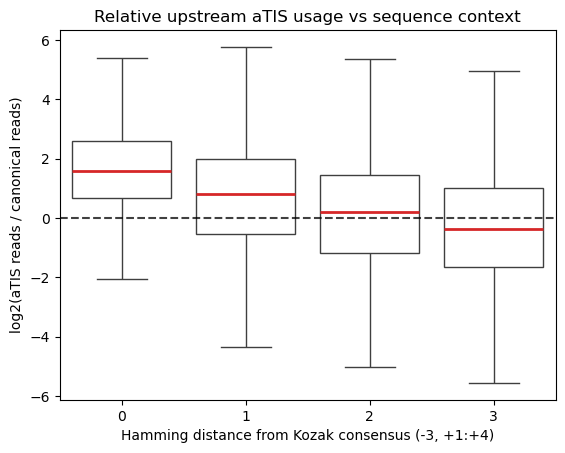

In [175]:
sns.boxplot(
    filtered_seq_annotated[filtered_seq_annotated['RecatTISType'].isin(['Extended', 'uORF'])],
    x='KozakMajorHammingDistance', y='SampleNormalizedLFC',
    medianprops={'color': 'tab:red', 'linewidth': 2},
    boxprops={'facecolor': 'white'},
    showfliers=False
)
plt.gca().axhline(0, linestyle='dashed', color='black', alpha=0.75)
plt.title('Relative upstream aTIS usage vs sequence context')
plt.xlabel('Hamming distance from Kozak consensus (-3, +1:+4)')
plt.ylabel('log2(aTIS reads / canonical reads)')

# Mechanistic model of leaky ribosome scanning

In [31]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

feature_table = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/glm_model_inputs.csv')
feature_table = feature_table.assign(
    CanonicalUTRLength = lambda x: x['CanonicalUTRLength'] / 1000,
    NumUpstreamNonATG=lambda x: x['NumUpstreamTIS'] - x['NumUpstreamATG']
)

model = smf.glm(
    formula="""
    TISCounts ~ 
        KozakMajorHammingDistance +
        NumUpstreamATG +
        NumUpstreamNonATG +
        CanonicalUTRLength +
        Sample +
        KozakMajorHammingDistance:Sample +
        NumUpstreamATG:Sample +
        NumUpstreamNonATG:Sample +
        CanonicalUTRLength:Sample
    """,
    data=feature_table,
    family=sm.families.NegativeBinomial(),
    offset=feature_table["GeneRNASeqLogRPM"]
).fit(cov_type='HC0')

print(model.summary())

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:              TISCounts   No. Observations:               138190
Model:                            GLM   Df Residuals:                   138160
Model Family:        NegativeBinomial   Df Model:                           29
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -9.9729e+05
Date:                Mon, 23 Mar 2026   Deviance:                   9.9301e+05
Time:                        11:33:21   Pearson chi2:                 2.87e+08
No. Iterations:                   100   Pseudo R-squ. (CS):             0.8491
Covariance Type:                  HC0                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [45]:
def compute_fold_changes(result, X, factor_names, cell_lines, baseline_cell_line):
    """
    Computes fold-change and 95% CI for specified factors per cell line.
    
    Parameters:
        result: fitted GLM NB (with cov_type='HC0' for robust SEs)
        X: design matrix used for fitting (pandas DataFrame)
        factor_names: list of main factors to interpret (e.g., ['num_upstream_AUG', 'num_nearcognate'])
        cell_lines: list of all cell line names
        baseline_cell_line: the reference cell line in dummy coding
    Returns:
        pandas DataFrame with β, fold-change, 95% CI per factor per cell line
    """
    cov = result.cov_params()
    params = result.params
    
    records = []

    for factor in factor_names:
        # main effect
        beta_main = params.get(factor, 0.0)
        
        for cell_line in cell_lines:
            # start with main effect
            beta_eff = beta_main
            
            if cell_line != baseline_cell_line:
                # check for interaction term
                interaction_term = f"{factor}:Sample[T.{cell_line}]"
                beta_int = params.get(interaction_term, 0.0)
                beta_eff += beta_int
                
                # variance propagation
                sub_cov = cov.reindex(index=[factor, interaction_term], columns=[factor, interaction_term], fill_value=0.0)

                var_eff = sub_cov.loc[factor, factor] + sub_cov.loc[interaction_term, interaction_term] + 2 * sub_cov.loc[factor, interaction_term]
            else:
                # baseline cell line variance
                var_eff = cov.loc[factor, factor]
            
            se_eff = np.sqrt(var_eff)
            # 95% CI in log space
            ci_low = beta_eff - 1.96 * se_eff
            ci_high = beta_eff + 1.96 * se_eff
            
            # convert to fold-change
            fold = np.exp(beta_eff)
            fold_low = np.exp(ci_low)
            fold_high = np.exp(ci_high)
            
            records.append({
                'sample': cell_line,
                'factor': factor,
                'beta': beta_eff,
                'fold_change': fold,
                'fold_change_CI_low': fold_low,
                'fold_change_CI_high': fold_high
            })
    
    return pd.DataFrame.from_records(records)

def plot_forest(fold_change_table, log_scale=True, figsize=(8,6), 
                factor_palette=predictor_palette, 
                loc='upper left', bbox_to_anchor=(1, 1), legend_label_map=None):
    """
    Creates a forest plot of fold-change effects per factor per cell line.
    
    Parameters:
        fold_change_table: DataFrame with columns:
            ['cell_line', 'factor', 'fold_change', 'fold_change_CI_low', 'fold_change_CI_high']
        log_scale: whether to plot on log scale (recommended)
        figsize: figure size
        title: plot title
    """
    df = fold_change_table.copy()
    
    # log transform if desired
    if log_scale:
        df['x'] = np.log(df['fold_change'])
        df['x_low'] = np.log(df['fold_change_CI_low'])
        df['x_high'] = np.log(df['fold_change_CI_high'])
        df['err_low'] = df['x'] - df['x_low']
        df['err_high'] = df['x_high'] - df['x']
        ref_line = 0
        xlabel = 'Log Fold-Change'
    else:
        df['x'] = df['fold_change']
        df['err_low'] = df['fold_change'] - df['fold_change_CI_low']
        df['err_high'] = df['fold_change_CI_high'] - df['fold_change']
        ref_line = 1
        xlabel = 'Fold-Change'
    
    # create a numeric y-position
    df['y_pos'] = df.groupby('factor').cumcount()
    # adjust spacing to separate factors
    factor_offsets = {f:i*(df['y_pos'].max()+2) for i,f in enumerate(df['factor'].unique())}
    df['y'] = df.apply(lambda r: r['y_pos'] + factor_offsets[r['factor']], axis=1)
    
    plt.figure(figsize=figsize)
    
    # plot points and error bars
    for idx, row in df.iterrows():
        plt.errorbar(row['x'], row['y'], xerr=[[row['err_low']], [row['err_high']]],
                     fmt='o', color=factor_palette[row['factor']], capsize=4)
    
    # y-ticks: show cell line names where possible
    # to avoid overlaps, only show the first occurrence per factor
    yticks = []
    yticklabels = []
    for f in df['factor'].unique():
        sub = df[df['factor'] == f]
        for _, r in sub.iterrows():
            yticks.append(r['y'])
            yticklabels.append(f"{r['sample']}")
    
    plt.yticks(yticks, yticklabels)
    
    # reference line
    plt.axvline(ref_line, color='gray', linestyle='--')
    
    plt.xlabel(xlabel)
    plt.ylabel('Cell line')
    
    # legend
    if legend_label_map is None:
        legend_label_map = {label: label for label in factor_palette.keys()}
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=legend_label_map[f])
               for f, c in factor_palette.items()]
    plt.legend(handles=handles, title='Factor', bbox_to_anchor=bbox_to_anchor, loc=loc)
    
    plt.gca().invert_yaxis()
    return plt.gcf(), plt.gca()

In [33]:
fold_change_table = compute_fold_changes(
    model, feature_table, 
    predictor_order,
   sample_order, 'HeLa'
)

Text(0.5, 1.0, 'Effects of predictive factors on canonical translation efficiency')

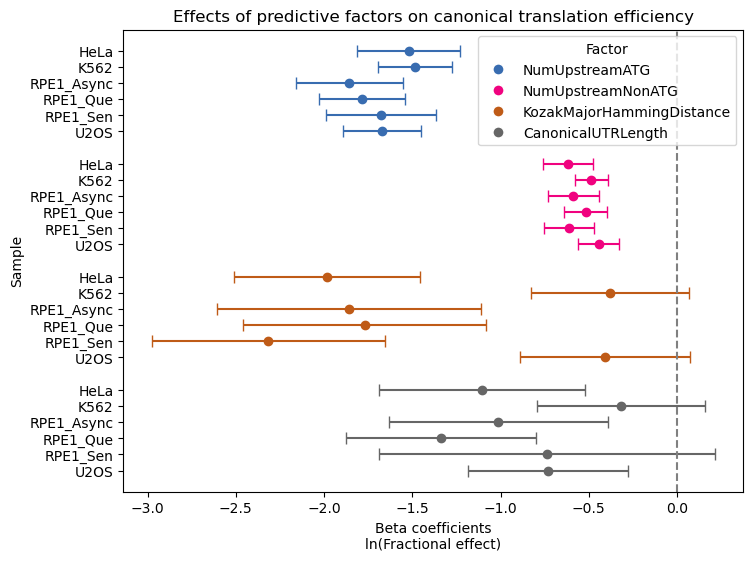

In [46]:
plot_forest(fold_change_table, figsize=(8, 6), log_scale=True, loc='upper right')
plt.ylabel('Sample')
plt.xlabel('Beta coefficients\nln(Fractional effect)')
plt.title('Effects of predictive factors on canonical translation efficiency')

Text(0.5, 1.0, 'Effects of predictive factors on canonical translation efficiency')

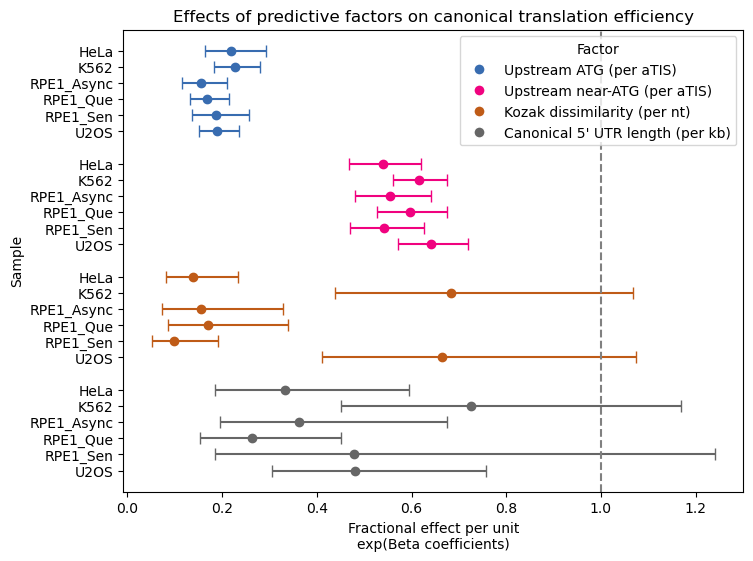

In [49]:
fig, ax = plot_forest(
    fold_change_table, figsize=(8, 6), log_scale=False, loc='upper right', 
    legend_label_map={
        'NumUpstreamATG': 'Upstream ATG (per aTIS)',
        'NumUpstreamNonATG': 'Upstream near-ATG (per aTIS)',
        'KozakMajorHammingDistance': 'Kozak dissimilarity (per nt)',
        'CanonicalUTRLength': "Canonical 5' UTR length (per kb)"
    }
)
plt.ylabel('Sample')
plt.xlabel('Fractional effect per unit\nexp(Beta coefficients)')
plt.title('Effects of predictive factors on canonical translation efficiency')

# Visualization of individual example transcripts

In [241]:
tis_summary = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/deseq2_tis_summary_statistics.csv')
vst_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/translation_efficiency_vst_matrix.csv', index_col=0)
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
tis_mask = riboseq_counts >= 5
# riboseq_counts_masked = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts_masked.csv', index_col=0)
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)
rna_mask = rna_counts >= 5
# rna_counts_masked = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts_masked.csv', index_col=0)
masked_te_matrix = vst_log_te_matrix[tis_mask & rna_mask].dropna(how='all')

In [242]:
tis_summary[tis_summary['Symbol'] == 'EIF2B1']

,TIS,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,LogTEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxLogRiboOverRNA,MaxLogTESample,MinLogRiboOverRNA,MinLogTESample,MaxLFCSamplePair,MaxLFCSamplePair.1,MinLFC,MinLFCSamplePair,MinDiffQValDirection,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff,LeaveOneOutLargestDeltaVariance,LeaveOneOutLargestDeltaRange,CandidateOutlier
14359,ENST00000424014.7_42_chr12:123633644:-,ENST00000424014.7,EIF2B1,ENSG00000111361.14,protein_coding,CTG,42.0,Extended,True,334.0,LARRRRGRRTRSRQRGRLGSPGAPQQEDAMDDKELIEYFKSQMKED...,6.0,0.395325,128,6.229594,U2OS,8,0.748864,RPE1_Que,0.583276,U2OS,-0.921747,K562,1.609255,U2OS/RPE1_Que,-1.314080,RPE1_Que/HeLa,1.0,7.900534e-06,U2OS/K562,0.249772,1.000000,4.499888,-0.125170,-0.255739,U2OS
14360,ENST00000424014.7_129_chr12:123633557:-,ENST00000424014.7,EIF2B1,ENSG00000111361.14,protein_coding,ATG,129.0,Annotated,True,305.0,MDDKELIEYFKSQMKEDPDMASAVAAIRTLLEFLKRDKGETIQGLR...,6.0,1.245627,650,23.995305,K562,18,0.440380,HeLa,1.389004,K562,-1.929283,HeLa,3.583575,K562/HeLa,-1.251101,RPE1_Que/K562,1.0,2.516795e-20,K562/HeLa,0.010006,1.000000,17.599424,-1.026553,-2.088680,HeLa
14361,ENST00000424014.7_186_chr12:123632402:-,ENST00000424014.7,EIF2B1,ENSG00000111361.14,protein_coding,ATG,186.0,Truncated,True,286.0,MASAVAAIRTLLEFLKRDKGETIQGLRANLTSAIETLCGVDSSVAV...,1.0,NaN,22,0.421233,HeLa,0,0.000000,RPE1_Que,-1.977542,HeLa,-1.977542,HeLa,-1.640423,RPE1_Sen/HeLa,-4.704515,K562/HeLa,-1.0,2.572007e-04,K562/HeLa,0.118193,0.310748,2.662321,-inf,0.000000,HeLa
14362,ENST00000537073.1_122_chr12:123633644:-,ENST00000537073.1,EIF2B1,ENSG00000111361.14,protein_coding,CTG,122.0,Extended,False,251.0,LARRRRGRRTRSRQRGRLGSPGAPQQEDAMDDKELIEYFKSQMKED...,6.0,0.395325,128,6.229594,U2OS,8,0.748864,RPE1_Que,0.583276,U2OS,-0.921747,K562,1.609255,U2OS/RPE1_Que,-1.314080,RPE1_Que/HeLa,1.0,7.900534e-06,U2OS/K562,0.249772,1.000000,4.499888,-0.125170,-0.255739,U2OS
14363,ENST00000537073.1_209_chr12:123633557:-,ENST00000537073.1,EIF2B1,ENSG00000111361.14,protein_coding,ATG,209.0,Annotated,False,222.0,MDDKELIEYFKSQMKEDPDMASAVAAIRTLLEFLKRDKGETIQGLR...,5.0,1.500323,650,23.995305,K562,0,0.000000,RPE1_Sen,1.389004,K562,-1.929283,HeLa,6.716164,U2OS/RPE1_Sen,-7.709550,RPE1_Sen/K562,1.0,2.906732e-20,K562/HeLa,0.000446,1.000000,16.186095,-1.208289,-2.088680,HeLa
14364,ENST00000452159.6_44_chr12:123633644:-,ENST00000452159.6,EIF2B1,ENSG00000111361.14,protein_coding,CTG,44.0,Other,False,155.0,LARRRRGRRTRSRQRGRLGSPGAPQQEDAMDDKELIEYFKSQMKED...,6.0,0.395325,128,6.229594,U2OS,8,0.748864,RPE1_Que,0.583276,U2OS,-0.921747,K562,1.609255,U2OS/RPE1_Que,-1.314080,RPE1_Que/HeLa,1.0,7.900534e-06,U2OS/K562,0.249772,1.000000,4.499888,-0.125170,-0.255739,U2OS
14365,ENST00000452159.6_140_chr12:123633548:-,ENST00000452159.6,EIF2B1,ENSG00000111361.14,protein_coding,AAG,140.0,Other,False,123.0,KELIEYFKSQMKEDPDMASAVAAIRTLLEFLKRDKGETIQGLRANL...,5.0,2.436461,155,2.967777,HeLa,3,0.280824,RPE1_Que,0.552854,HeLa,-3.385908,RPE1_Async,1.316191,U2OS/RPE1_Async,-3.122249,RPE1_Async/HeLa,-1.0,9.473770e-08,K562/HeLa,0.647318,1.000000,6.834595,-1.402256,-1.738850,HeLa
14366,ENST00000543940.1_13_chr12:123633644:-,ENST00000543940.1,EIF2B1,ENSG00000111361.14,protein_coding,CTG,13.0,Other,False,124.0,LARRRRGRRTRSRQRGRLGSPGAPQQEDAMDDKELIEYFKSQMKED...,6.0,0.306584,128,6.229594,U2OS,13,0.902777,RPE1_Sen,0.583276,U2OS,-0.921747,K562,1.551064,U2OS/K562,-1.256005,K562/HeLa,1.0,8.289305e-06,U2OS/K562,0.308291,1.000000,4.570443,-0.103330,-0.432565,U2OS
14367,ENST00000543940.1_109_chr12:123633548:-,ENST00000543940.1,EIF2B1,ENSG00000111361.14,protein_coding,AAG,109.0,Other,False,92.0,KELIEYFKSQMKEDPDMASAVAAIRTLLEFLKRDKGETIQGLRANL...,5.0,2.436461,155,2.967777,HeLa,3,0.280824,RPE1_Que,0.552854,HeLa,-3.385908,RPE1_Async,1.316191,U2OS/RPE1_Async,-3.122249,RPE1_Async/HeLa,-1.0,9.473770e-08,K562/HeLa,0.647318,1.000000,6.834595,-1

In [254]:
tis_summary[
    tis_summary['Symbol'].str.contains('EIF2A') & 
    tis_summary['MANE_Select']
].sort_values('Symbol')

,TIS,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,LogTEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxLogRiboOverRNA,MaxLogTESample,MinLogRiboOverRNA,MinLogTESample,MaxLFCSamplePair,MaxLFCSamplePair.1,MinLFC,MinLFCSamplePair,MinDiffQValDirection,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff,LeaveOneOutLargestDeltaVariance,LeaveOneOutLargestDeltaRange,CandidateOutlier
4934,ENST00000460851.6_16_chr3:150546802:+,ENST00000460851.6,EIF2A,ENSG00000144895.13,protein_coding,ATG,16.0,Annotated,True,585.0,MAPSTPLLTVRGSEGLYMVNGPPHFTESTVFPRESGKNCKVCIFSK...,6.0,0.332726,148,4.429902,K562,16,0.789930,RPE1_Sen,-0.570660,HeLa,-1.997586,RPE1_Sen,0.861766,U2OS/RPE1_Sen,-1.512283,RPE1_Sen/HeLa,-1.0,1.052175e-02,RPE1_Sen/HeLa,0.511394,1.000000,1.686668,-0.149370,-0.489019,HeLa
8189,ENST00000199389.11_92_chr7:6059083:-,ENST00000199389.11,EIF2AK1,ENSG00000086232.14,protein_coding,ATG,92.0,Annotated,True,630.0,MQGGNSGVRKREEEGDGAGAVAAPPAIDFPAEGPDPEYDESDVPAE...,3.0,2.216071,30,2.059377,RPE1_Que,0,0.000000,RPE1_Async,-1.444831,RPE1_Que,-4.039313,HeLa,6.660913,RPE1_Que/RPE1_Async,-7.682607,U2OS/RPE1_Que,1.0,7.930804e-07,RPE1_Que/K562,0.007537,0.980890,3.977888,-2.215545,-2.562037,RPE1_Que
8190,ENST00000199389.11_392_chr7:6050022:-,ENST00000199389.11,EIF2AK1,ENSG00000086232.14,protein_coding,ATG,392.0,Truncated,True,530.0,MGLLSSFTCSDEFSSLRLHHNRAITHLMRSAKERVRQDPCEDISRI...,2.0,3.837116,95,1.818960,HeLa,0,0.000000,RPE1_Async,-1.992634,HeLa,-4.762875,K562,-0.791138,RPE1_Que/K562,-7.126678,U2OS/HeLa,-1.0,1.869667e-09,K562/HeLa,0.029034,1.000000,7.191142,-inf,-2.770241,HeLa
39657,ENST00000199389.11_23_chr7:6059152:-,ENST00000199389.11,EIF2AK1,ENSG00000086232.14,protein_coding,CTG,23.0,Extended,True,653.0,LQHRSVAVLGWPAGWAAARARPAMQGGNSGVRKREEEGDGAGAVAA...,3.0,1.396948,16,0.590654,K562,0,0.000000,RPE1_Async,-3.160220,RPE1_Que,-5.442446,HeLa,4.786875,RPE1_Que/RPE1_Async,-5.808503,U2OS/RPE1_Que,-1.0,4.151291e-03,U2OS/RPE1_Que,0.088096,0.733541,1.326772,-1.212240,-1.674429,RPE1_Que
39658,ENST00000199389.11_38_chr7:6059137:-,ENST00000199389.11,EIF2AK1,ENSG00000086232.14,protein_coding,GTG,38.0,Extended,True,648.0,VAVLGWPAGWAAARARPAMQGGNSGVRKREEEGDGAGAVAAPPAID...,6.0,2.716817,72,5.679923,U2OS,5,0.095735,HeLa,-1.154901,RPE1_Async,-5.451447,HeLa,5.091253,RPE1_Async/HeLa,-0.581492,U2OS/RPE1_Async,1.0,2.768469e-10,RPE1_Async/HeLa,0.004248,1.000000,7.185901,-2.226490,-2.561292,HeLa
63359,ENST00000199389.11_47_chr7:6059128:-,ENST00000199389.11,EIF2AK1,ENSG00000086232.14,protein_coding,CTG,47.0,Extended,True,645.0,LGWPAGWAAARARPAMQGGNSGVRKREEEGDGAGAVAAPPAIDFPA...,3.0,1.414461,70,3.664467,U2OS,0,0.000000,RPE1_Async,-2.792916,U2OS,-4.932854,HeLa,5.724198,U2OS/RPE1_Sen,-5.124820,RPE1_Sen/K562,1.0,1.406619e-04,U2OS/HeLa,0.008270,0.495990,1.769344,-1.399911,-1.969348,HeLa
86501,ENST00000199389.11_119_chr7:6059056:-,ENST00000199389.11,EIF2AK1,ENSG00000086232.14,protein_coding,AAG,119.0,Truncated,True,621.0,KREEEGDGAGAVAAPPAIDFPAEGPDPEYDESDVPAEIQVLKEPLQ...,2.0,0.003694,28,2.565127,U2OS,0,0.000000,HeLa,-2.857672,U2OS,-2.943620,RPE1_Sen,7.663985,U2OS/K562,0.219207,U2OS/RPE1_Sen,1.0,1.150508e-05,U2OS/K562,0.007167,1.000000,2.794441,-inf,-0.085948,RPE1_Sen
2614,ENST00000233057.9_256_chr2:37147806:-,ENST00000233057.9,EIF2AK2,ENSG00000055332.20,protein_coding,ATG,256.0,Annotated,True,551.0,MAGDLSAGFFMEELNTYRQKQGVVLKYQELPNSGPPHDRRFTFQVI...,6.0,0.418877,97,4.030913,U2OS,12,0.902777,RPE1_Sen,0.331830,K562,-1.514232,RPE1_Sen,1.124816,K562/HeLa,-1.336527,RPE1_Que/K562,1.0,2.785836e-03,K562/HeLa,0.458233,1.000000,2.216131,-0.170753,-0.593217,RPE1_Sen
60980,ENST00000233057.9_241_chr2:37147821:-,ENST00000233057.9,EIF2AK2,ENSG00000055332.20,protein_coding,ATA,241.0,Extended,True,556.0,IREEEMAGDLSAGFFMEELNTYRQKQGVVLKYQELPNSGPPHDRRF...,4.0,0.653305,8,0.458058,U2OS,0,0.000000,RPE1_Que,-2.325274,RPE1_Async,-4.298923,HeLa,3.560404,U2OS/RPE1_Sen,-4.290809,RPE1

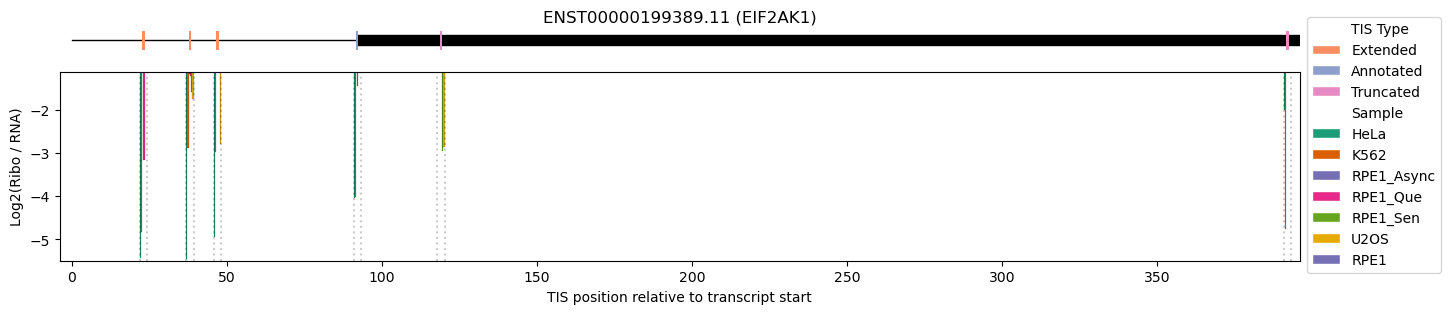

In [255]:
plot_tis_over_cell_lines(
    'ENST00000199389.11', tis_summary, masked_te_matrix,
    sample_palette=sample_palette, tis_type_palette=tistype_palette
)

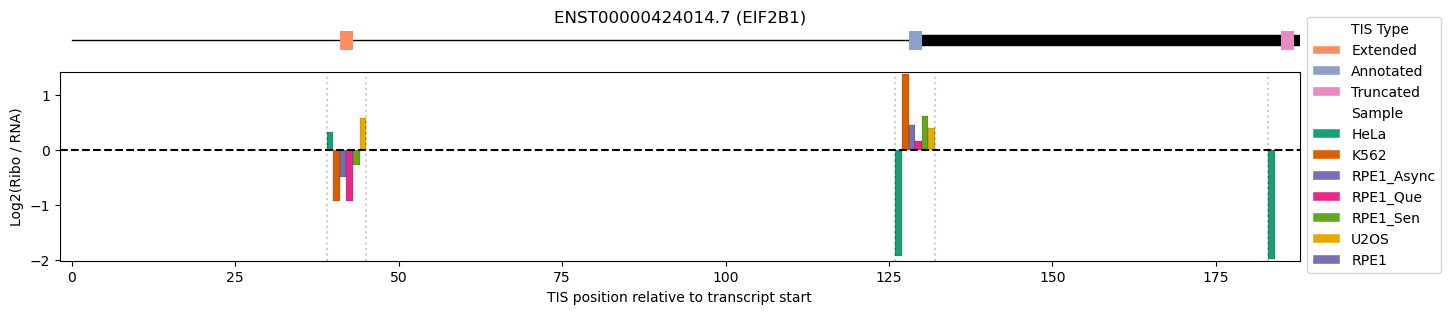

In [257]:
plot_tis_over_cell_lines(
    'ENST00000424014.7', tis_summary, masked_te_matrix,
    sample_palette=sample_palette, tis_type_palette=tistype_palette, position_width=6
)

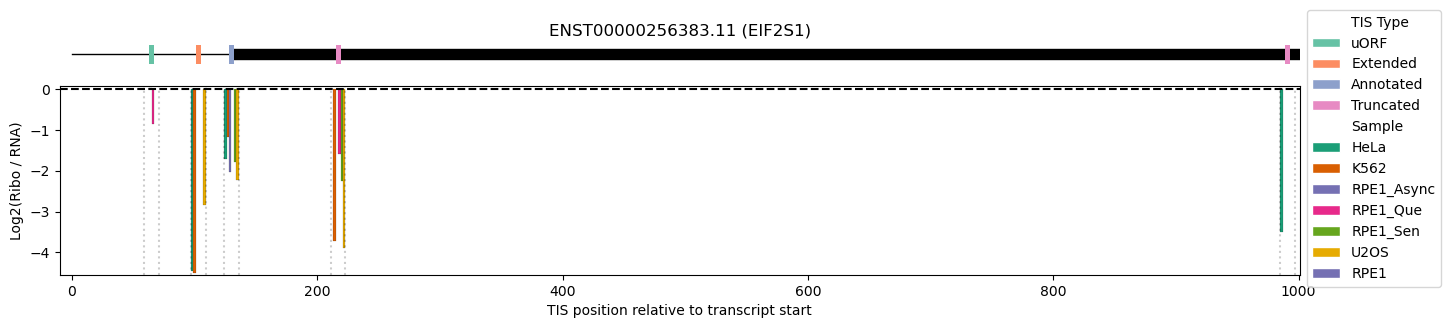

In [260]:
plot_tis_over_cell_lines(
    'ENST00000256383.11', tis_summary, masked_te_matrix,
    sample_palette=sample_palette, tis_type_palette=tistype_palette, position_width=12
)

In [264]:
outlier_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/alternative_translation_efficiency_outliers.csv', index_col=0)

In [269]:
continuous_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/alternative_translation_efficiency_continuous.csv', index_col=0)

In [266]:
outlier_df[outlier_df['CandidateOutlier'].isin(['K562', 'U2OS'])].head(n=10)

,TIS,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,LogTEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxLogRiboOverRNA,MaxLogTESample,MinLogRiboOverRNA,MinLogTESample,MaxLFCSamplePair,MaxLFCSamplePair.1,MinLFC,MinLFCSamplePair,MinDiffQValDirection,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff,LeaveOneOutLargestDeltaVariance,LeaveOneOutLargestDeltaRange,CandidateOutlier,AASeqDiffFromCanonical,AASeqDiff_ELMIdentifier,AASeqDiff_FunctionSiteName,AASeqDiff_Description
942,ENST00000558868.6_118_chr15:63048575:+,ENST00000558868.6,TPM1,ENSG00000140416.27,protein_coding,ATG,118.0,Other,False,152.0,MAGSSSLEAVRRKIRSLQEQADAAEERAGTLQRELDHERKLRETAE...,6.0,9.222846,228,9.710837,U2OS,35,1.731359,RPE1_Async,2.160471,K562,-5.487621,RPE1_Que,3.745792,U2OS/RPE1_Que,-7.878946,RPE1_Que/K562,-1.0,2.054188e-56,RPE1_Que/K562,1.899779e-11,0.92393,44.966063,-3.523321,-1.793522,K562,NaN,NaN,NaN,NaN
670,ENST00000359426.7_47_chr10:69318893:+,ENST00000359426.7,HK1,ENSG00000156515.26,protein_coding,CTG,47.0,Extended,True,935.0,LRRTDRPHACRPATPTASMIAAQLLAYYFTELKDDQVKKIDKYLYA...,6.0,3.697815,72,3.363783,RPE1_Async,18,0.593555,HeLa,-1.059509,HeLa,-6.777485,K562,4.648320,RPE1_Sen/K562,-5.991359,K562/HeLa,-1.0,1.727663e-34,K562/HeLa,1.063742e-03,1.00000,30.789377,-2.877308,-3.363821,K562,LRRTDRPHACRPATPTAS,CLV_NRD_NRD_1|CLV_PCSK_KEX2_1|CLV_PCSK_SKI1_1|...,PKA Phosphorylation site|SCF ubiquitin ligase ...,The TPxxS phospho-dependent degron binds the F...
2002,ENST00000246337.9_117_chr1:45012991:+,ENST00000246337.9,UROD,ENSG00000126088.15,protein_coding,ATG,117.0,Truncated,True,332.0,MRQAGRYLPEFRETRAAQDFFSTCRSPEACCELTLQPLRRFPLDAA...,6.0,2.565321,2248,82.986838,K562,8,0.153176,HeLa,1.276324,K562,-3.409150,HeLa,5.261865,K562/HeLa,-3.365084,RPE1_Que/K562,1.0,5.580661e-19,K562/HeLa,6.672937e-04,1.00000,15.077631,-1.343572,-1.575780,K562,MEANGLGPQGFPELKNDTFLRAAWGEETDYTPVWC,DEG_Nend_UBRbox_2|DOC_WW_Pin1_4|LIG_LIR_Nem_3|...,Atg8 protein family ligands|N-degron|WDR5 WD40...,The Class IV WW domain interaction motif is re...
2001,ENST00000434478.6_117_chr1:45012991:+,ENST00000434478.6,UROD,ENSG00000126088.15,protein_coding,ATG,117.0,Truncated,False,240.0,MRQAGRYLPEFRETRAAQDFFSTCRSPEACCELTLQPLRRFPLDAA...,6.0,2.549644,2248,82.986838,K562,8,0.153176,HeLa,1.276324,K562,-3.409150,HeLa,5.263087,K562/HeLa,-3.367207,RPE1_Que/K562,1.0,1.238300e-19,K562/HeLa,1.198136e-04,1.00000,14.985680,-1.173953,-1.575780,K562,MEANGLGPQGFPELKNDTFLRAAWGEETDYTPVWC,DEG_Nend_UBRbox_2|DOC_WW_Pin1_4|LIG_LIR_Nem_3|...,Atg8 protein family ligands|N-degron|WDR5 WD40...,The Class IV WW domain interaction motif is re...
524,ENST00000350320.11_114_chr7:35801170:+,ENST00000350320.11,SEPTIN7,ENSG00000122545.22,protein_coding,CTG,114.0,Extended,True,450.0,LRSAGAGRGGGEGMSVSARSAAAEERSVNSSTMVAQQKNLEGYVGF...,6.0,2.129475,198,18.139110,U2OS,8,0.295327,K562,1.927769,U2OS,-2.269706,K562,4.772615,U2OS/K562,-0.891877,K562/HeLa,1.0,5.725209e-13,U2OS/HeLa,7.186862e-02,1.00000,11.098748,-1.605506,-2.530362,U2OS,LRSAGAGRGGGEG,DEG_Nend_Nbox_1|MOD_GlcNHglycan,Glycosaminoglycan attachment site|N-degron,N-terminal motif that initiates protein degrad...
2109,ENST00000359856.11_118_chr1:183635665:-,ENST00000359856.11,ARPC5,ENSG00000162704.16,protein_coding,ATT,118.0,Extended,True,153.0,IGMSKNTVSSARFRKVDVDEYDENKFVDEEDGGDGQAGPDEGEVDS...,6.0,1.828970,150,7.420109,RPE1_Async,18,0.664485,K562,0.531562,RPE1_Sen,-3.112857,K562,3.965569,RPE1_Sen/K562,-1.846841,K562/HeLa,1.0,4.796869e-17,RPE1_Sen/K562,2.360395e-03,1.00000,13.692027,-1.086664,-1.538708,K562,IG,DEG_Nend_Nbox_1,N-degron,N-terminal motif that initiates protein degrad...
976,ENST00000336783.9_237_chr16:28823235:+,ENST00000336783.9,ATXN2L,ENSG00000168488.20,protein_coding,ATT,237.0,Extended,True,1083.0,IPLPDAAIMLKPQPLQQPSQPQQPPPTQQAVARRPPGGTSPPNGGL...,6.0,1.765776,66,1.879761,RPE1_Async,6,0.442990,K562,-2.190217,RPE1_Async,-5.802872,K562,4.

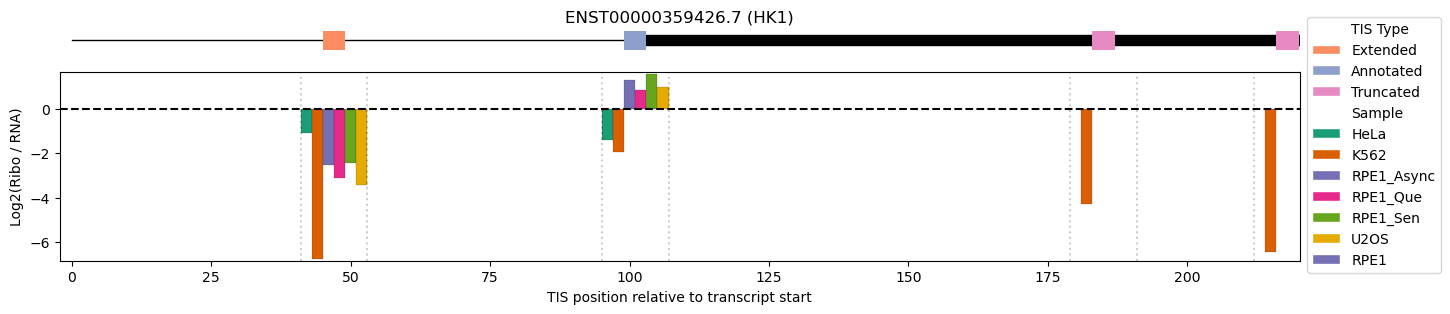

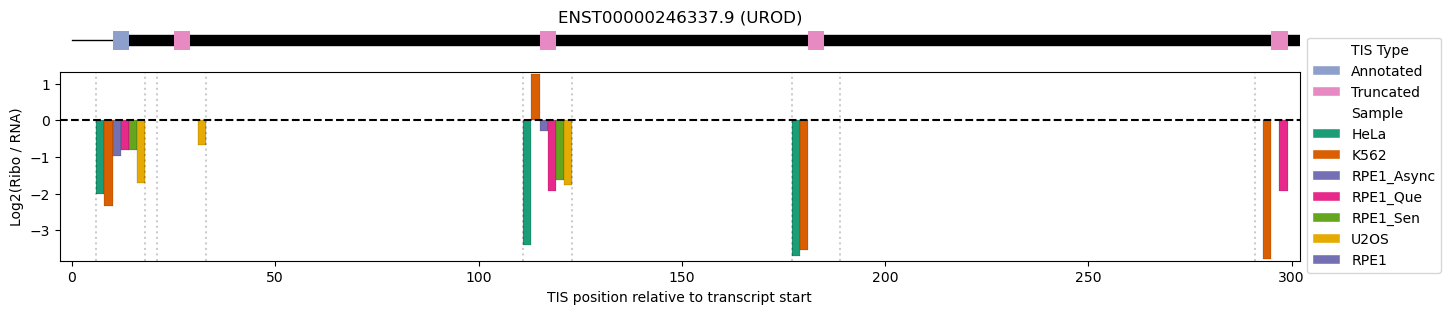

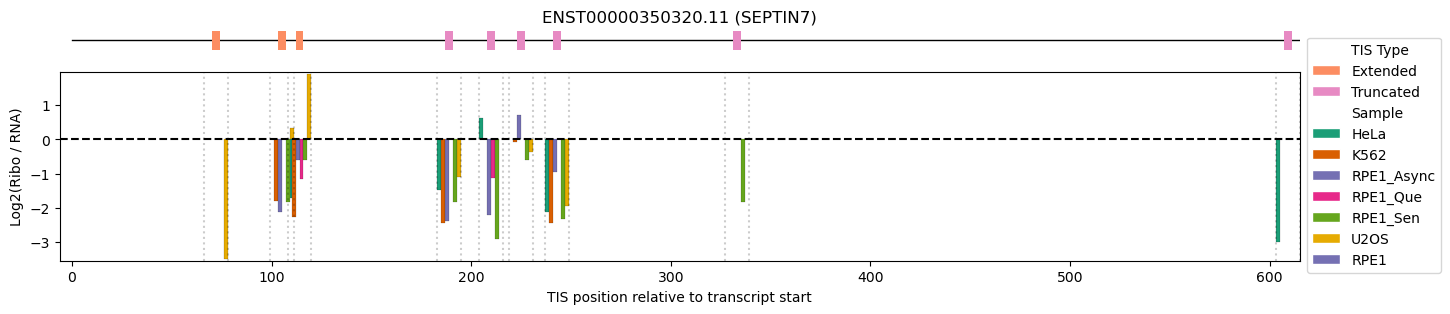

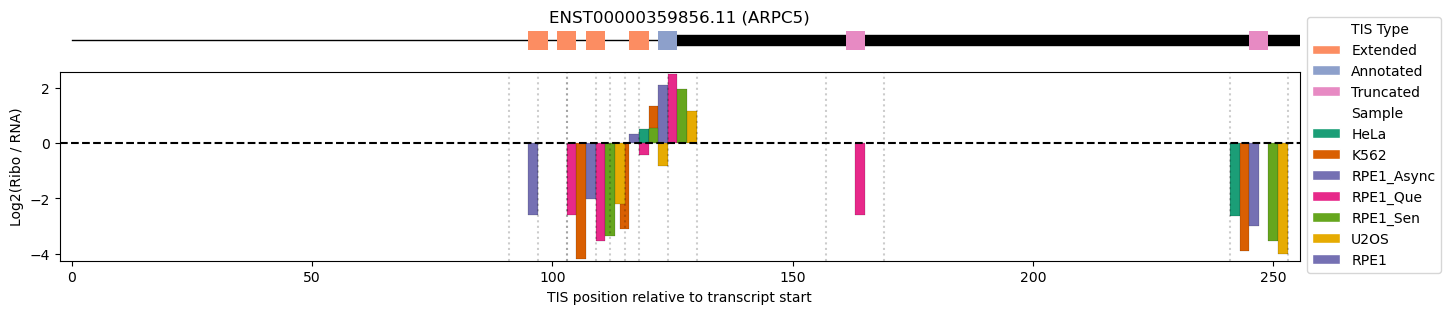

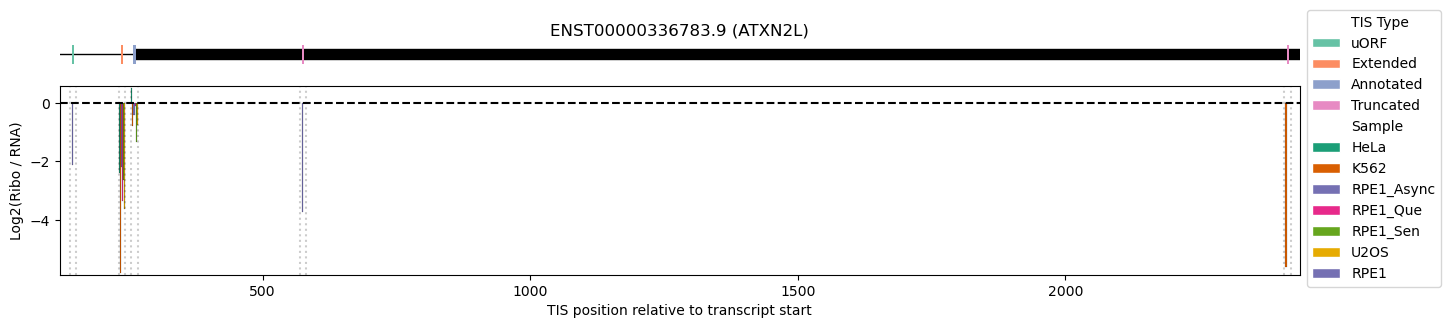

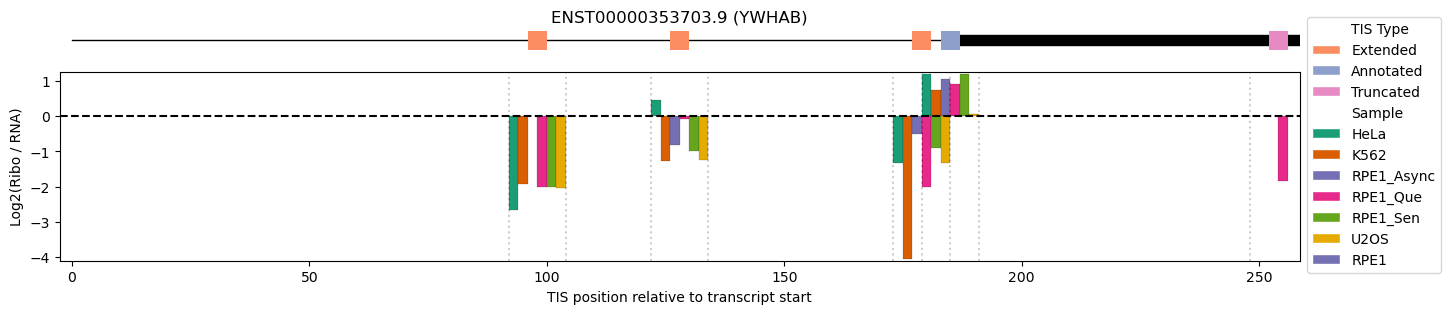

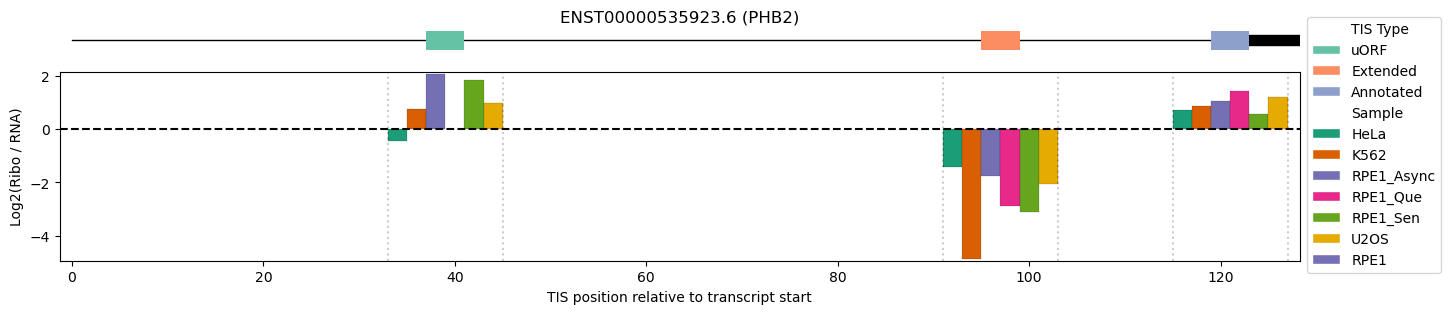

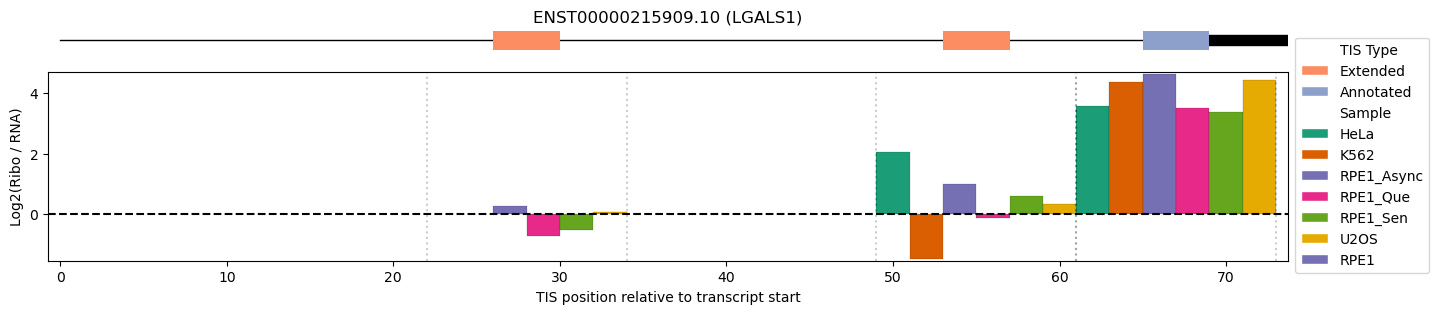

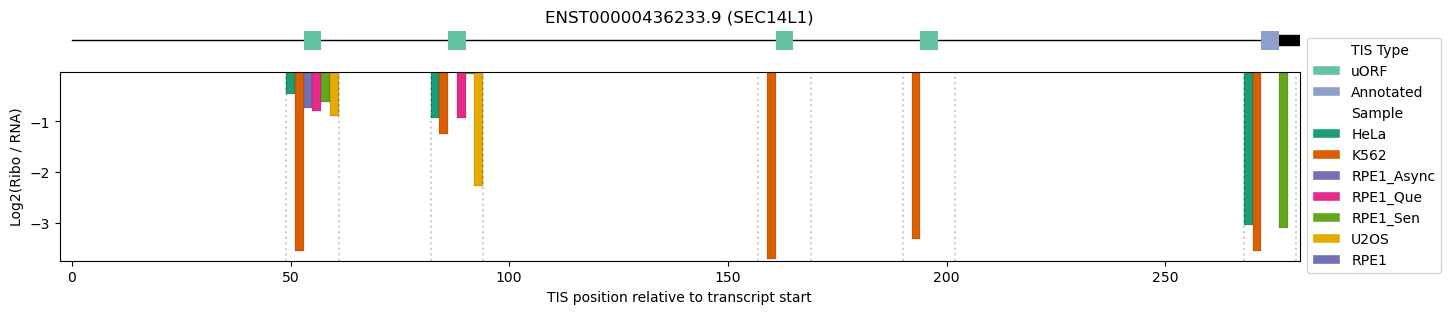

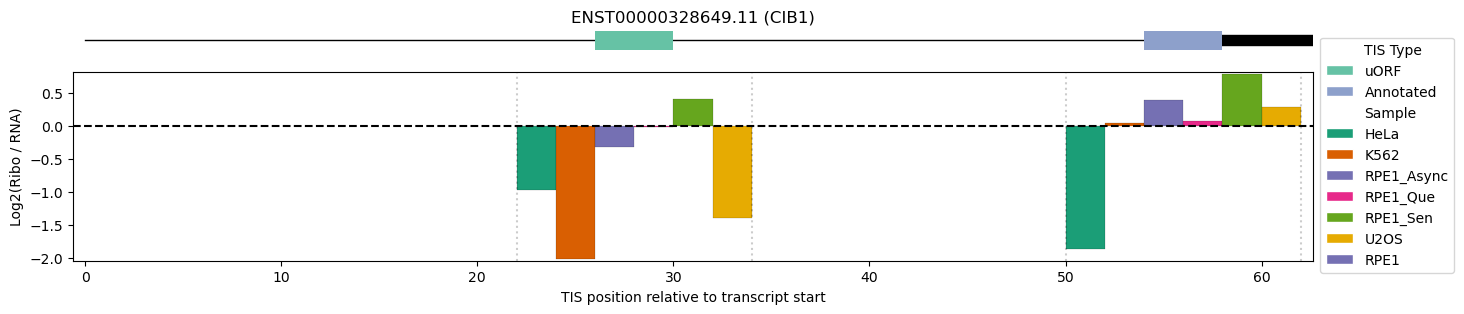

In [268]:
for tid in outlier_df[outlier_df['CandidateOutlier'].isin(['K562', 'U2OS']) & outlier_df['MANE_Select']].head(n=10)['Tid']:
    plot_tis_over_cell_lines(
        tid, tis_summary, masked_te_matrix,
        sample_palette=sample_palette, tis_type_palette=tistype_palette, position_width=12
    )
    plt.show()

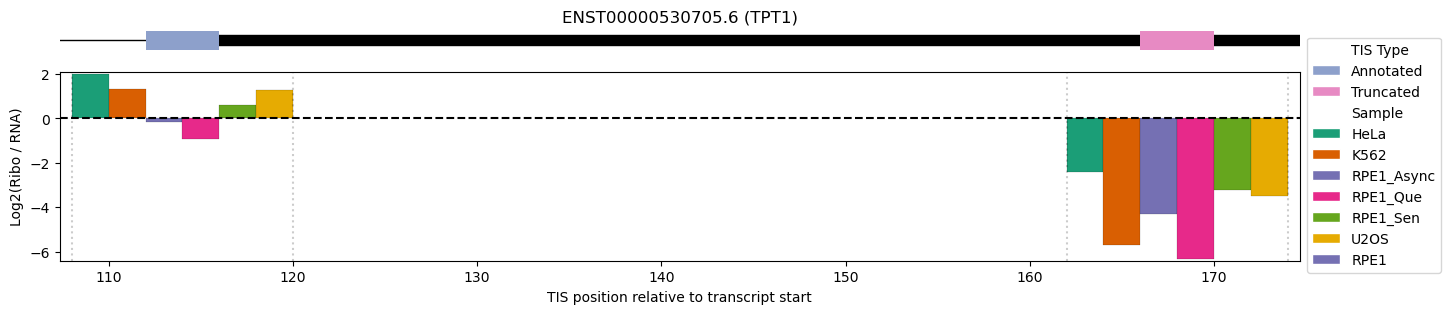

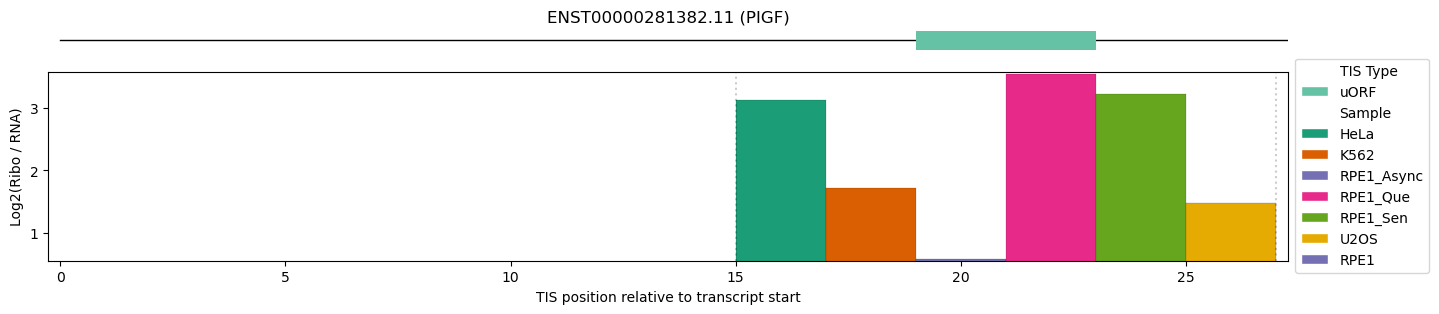

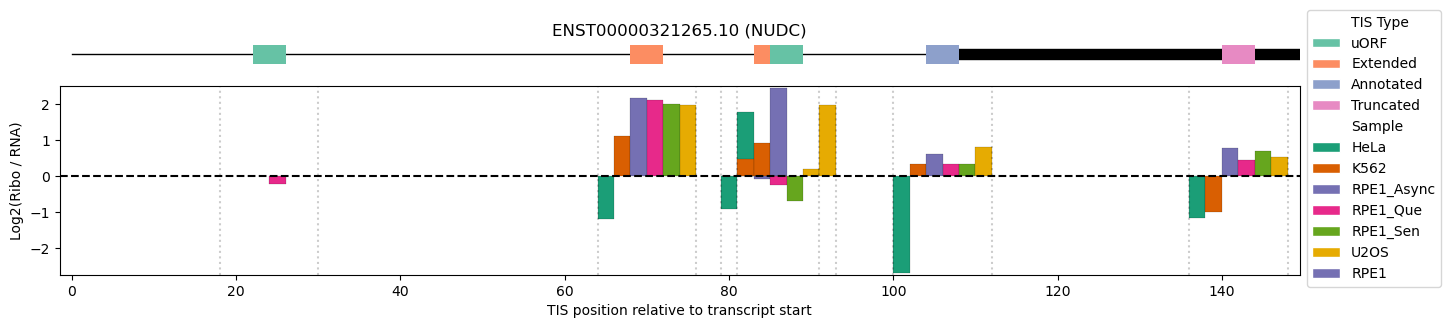

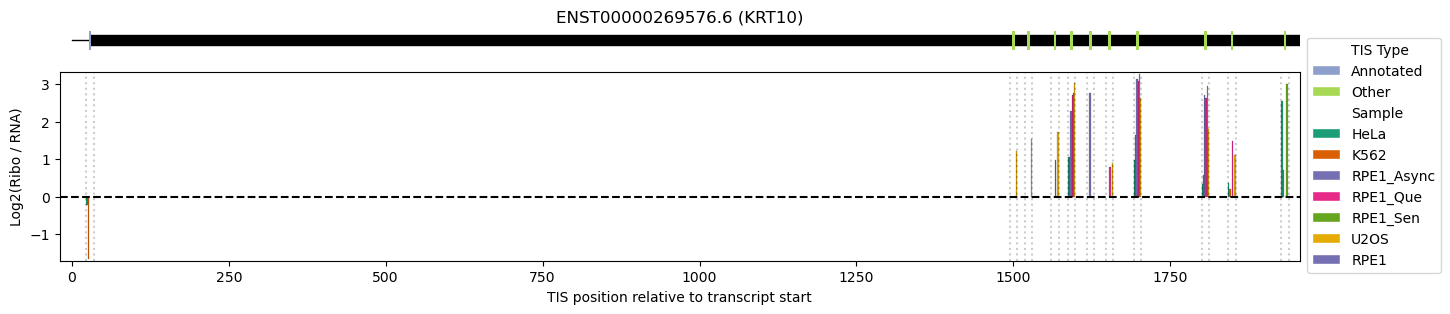

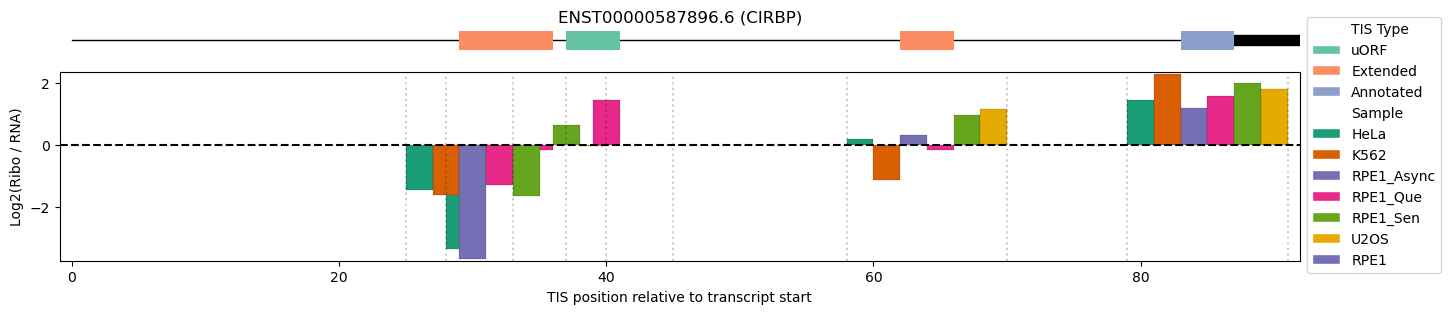

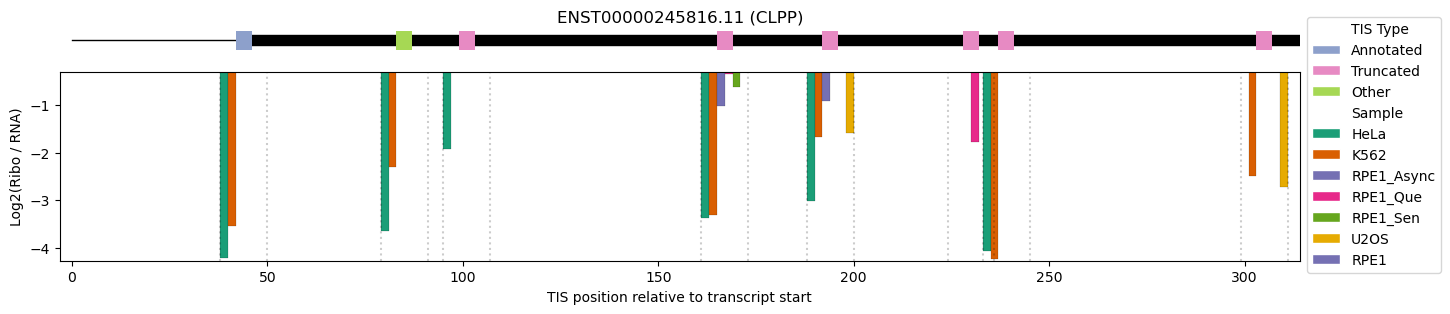

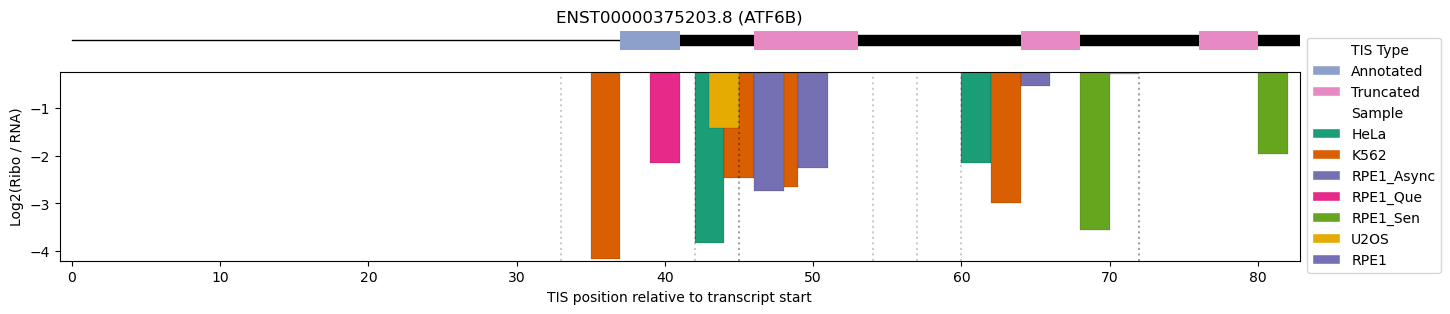

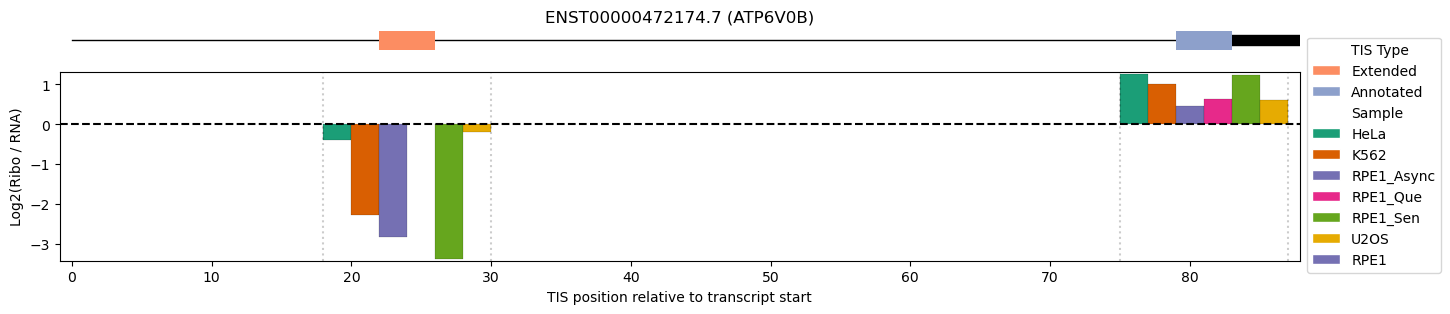

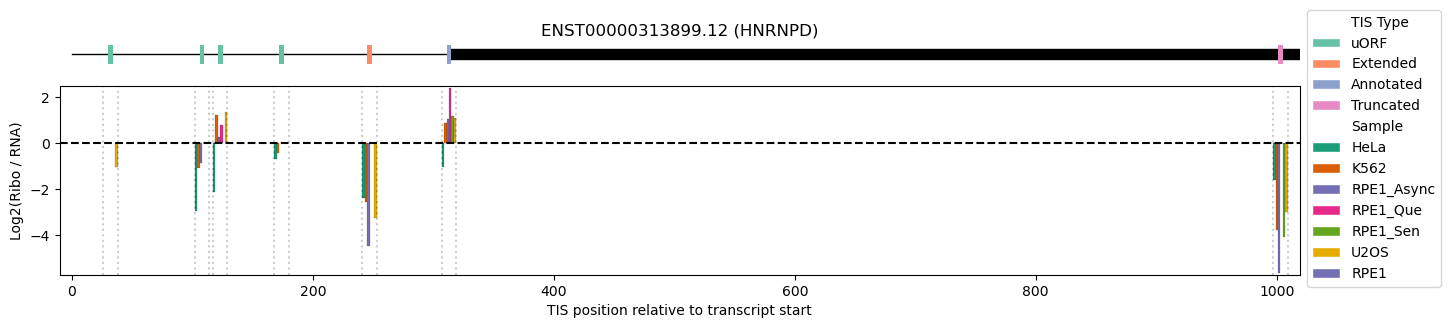

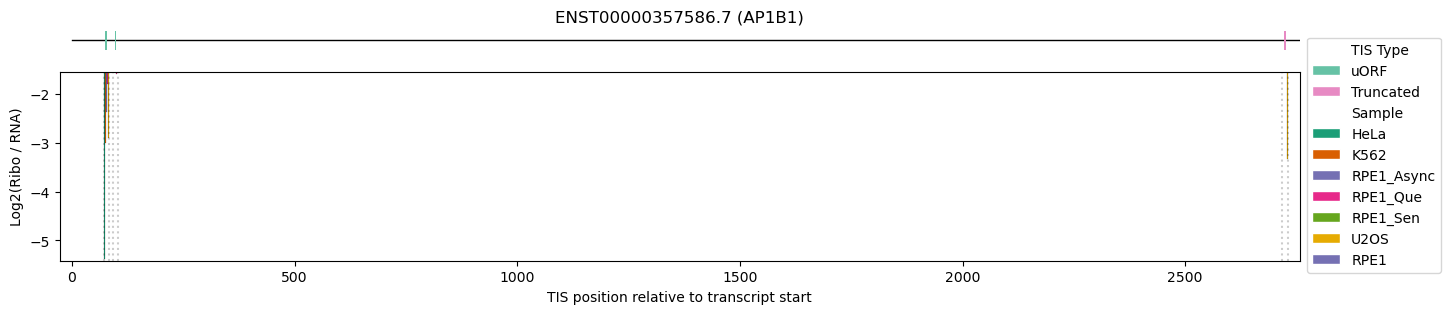

In [270]:
for tid in continuous_df[continuous_df['MANE_Select']].head(n=10)['Tid']:
    plot_tis_over_cell_lines(
        tid, tis_summary, masked_te_matrix,
        sample_palette=sample_palette, tis_type_palette=tistype_palette, position_width=12
    )
    plt.show()

# Differential analysis of RPE1 cell states

## All pairwise for context

In [93]:
pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/pairwise_wald/{f}', index_col=0)

vst_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/translation_efficiency_vst_matrix.csv', index_col=0)
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
tis_mask = riboseq_counts >= 5
# riboseq_counts_masked = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts_masked.csv', index_col=0)
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)
rna_mask = rna_counts >= 5
# rna_counts_masked = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts_masked.csv', index_col=0)
masked_te_matrix = vst_log_te_matrix[tis_mask & rna_mask].dropna(how='all')

# TIS metadata
replicate_level_tis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/per_rep/all_samples_filtered_with_protein_seq.csv')
replicate_level_tis_df = replicate_level_tis_df.assign(
    TIS=replicate_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)
tis_metadata = replicate_level_tis_df[
    ['TIS', 'Tid', 'Symbol', 'Gid', 'GeneType', 'GenomeStart', 'StartCodon', 'Start', 'RecatTISType', 'MANE_Select', 'AALen', 'AASeq']
].sort_values(by='AASeq').drop_duplicates(
    ['TIS']
)

In [ ]:
n_diff_tis_paired = dict()
n_diff_genes_by_tis_paired = dict()
for keypair in pairwise_wald_tests:
    significant_tis_subset = pairwise_wald_tests[keypair][
        (pairwise_wald_tests[keypair]['lfcSE'] < 1) & 
        (pairwise_wald_tests[keypair]['padj'] < 0.05)
    ]
    n_diff_tis_paired[keypair] = len(significant_tis_subset)
    significant_tis_subset['Tid'] = significant_tis_subset.index.str.split('_').str[0]
    significant_tis_subset = significant_tis_subset.merge(tis_metadata[['Tid', 'Symbol']], how='left')
    n_diff_genes_by_tis_paired[keypair] = len(significant_tis_subset.drop_duplicates(['Symbol']))

In [96]:
diff_count_matrix = pd.DataFrame(pd.Series(n_diff_tis_paired, name='NDiffTIS')).reset_index(names=['TestSample', 'ReferenceSample']).pivot(
    index='ReferenceSample', columns='TestSample', values='NDiffTIS'
).reindex(index=sample_order, columns=sample_order)

diff_gene_count_matrix = pd.DataFrame(pd.Series(n_diff_genes_by_tis_paired, name='NDiffGeneTranslation')).reset_index(names=['TestSample', 'ReferenceSample']).pivot(
    index='ReferenceSample', columns='TestSample', values='NDiffGeneTranslation'
).reindex(index=sample_order, columns=sample_order)

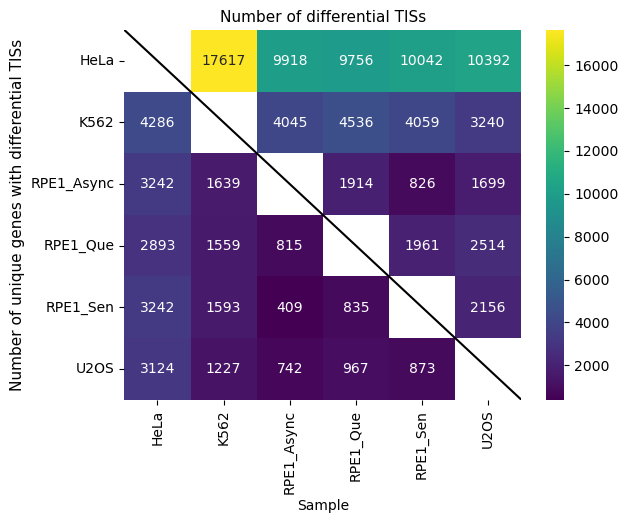

In [123]:
sns.heatmap(
    diff_count_matrix.fillna(0) + diff_gene_count_matrix.fillna(0).T, 
    mask=(diff_count_matrix.isna() & diff_gene_count_matrix.T.isna()),
    cmap='viridis', annot=True, fmt='.0f'
    # cbar_kws={'label': 'Number of differential TISs at FDR < 0.05'}
)
plt.xlabel('Sample')
plt.ylabel('Number of unique genes with differential TISs', fontsize=11)
plt.title('Number of differential TISs', fontsize=11)
plt.axline([0, 0], [6, 6], color='black')

## Just RPE1

In [127]:
from scripts.analysis_pipelines import *

from gseapy import Msigdb
import gseapy as gp
msig = Msigdb()

curated_genesets = pd.concat({
    name: pd.DataFrame(pd.Series(msig.get_gmt(category=ds, dbver='2026.1.Hs')).explode().rename('Gene')).reset_index(names=['Geneset'])
    for ds, name in zip(['c2.cp.reactome', 'c5.go.bp', 'c5.go.cc', 'c5.go.mf'], ['Reactome', 'GOBP', 'GOCC', 'GOMF'])
}, axis=0).droplevel(1, axis=0).reset_index(names=['Collection'])

In [128]:
rpe1_samples = ['RPE1_Async', 'RPE1_Que', 'RPE1_Sen']

rpe1_pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    rpe1_pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald/{f}', index_col=0)

rpe1_tis_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/translation_efficiency_vst_matrix.csv', index_col=0)
rpe1_tis_matrix = rpe1_tis_matrix[tis_mask.reindex_like(rpe1_tis_matrix) & rna_mask.reindex_like(rpe1_tis_matrix)]

rpe1_lfc_block = extract_TIS_block(comparison_metric='log2FoldChange', pairwise_dict=rpe1_pairwise_wald_tests, masked_tis_matrix=rpe1_tis_matrix)
rpe1_qval_block = extract_TIS_block(comparison_metric='padj', pairwise_dict=rpe1_pairwise_wald_tests, masked_tis_matrix=rpe1_tis_matrix)

100%|██████████| 3/3 [00:00<00:00, 20.58it/s]


In [129]:
rpe1_pairwise_wald_rna_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald_rna'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    rpe1_pairwise_wald_rna_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald_rna/{f}', index_col=0)

In [130]:
# take significant rna changes and significant TIS changes and intersect them
def merge_tis_and_rna_deseqs(tis_df, rna_df, 
                             min_tis_effect=1, min_rna_effect=1, 
                             max_tis_p=0.05, max_rna_p=0.05, 
                             effect_column='log2FoldChange', p_column='padj'):
    significant_tis_df = tis_df.copy()
    top_tis_per_gene = significant_tis_df[
        significant_tis_df['RecatTISType'] == 'Annotated' # presumably if any of the annotated TISs shifts, a non-canonical one must compensate
    ].groupby('Gid')[p_column].idxmin()
    consolidated_significant_tis_df = significant_tis_df.loc[
        top_tis_per_gene, :
    ]
    consolidated_significant_tis_df['SigRibo'] = (
        (consolidated_significant_tis_df[effect_column].abs() > min_tis_effect) &
        (consolidated_significant_tis_df[p_column].abs() < max_tis_p)
    )

    significant_rna_df = rna_df.copy()
    significant_rna_df['SigRNA'] = (
        (significant_rna_df[effect_column].abs() > min_rna_effect) &
        (significant_rna_df[p_column].abs() < max_rna_p)
    )

    add_prefix = lambda x, c: x + '_' + c

    merged = consolidated_significant_tis_df[['TIS', effect_column, p_column, 'lfcSE', 'Symbol', 'SigRibo']].rename(
        {c: add_prefix('Ribo', c) for c in [effect_column, p_column, 'lfcSE']}, axis=1
    ).merge(
        significant_rna_df[[effect_column, p_column, 'lfcSE', 'Symbol', 'SigRNA']].rename(
            {c: add_prefix('RNA', c) for c in [effect_column, p_column, 'lfcSE']}, axis=1
        ), left_on=['Symbol'], right_on=['Symbol'], how='inner'
    )

    return merged

In [131]:
def plot_cross_scatter(merged_tis_rna_df, max_lfc_se = 1):
    plot_df = merged_tis_rna_df.copy()

    plot_df.loc[:, 'Significant'] = 'Neither'
    plot_df.loc[plot_df['SigRibo'], 'Significant'] = 'Ribo'
    plot_df.loc[plot_df['SigRNA'], 'Significant'] = 'RNA'
    plot_df.loc[plot_df['SigRibo'] & plot_df['SigRNA'], 'Significant'] = 'Both'

    filtered_plot_df = plot_df[
        (plot_df['Ribo_lfcSE'] < max_lfc_se) &
        (plot_df['RNA_lfcSE'] < max_lfc_se)
    ]

    sns.scatterplot(
        filtered_plot_df[filtered_plot_df['Significant'] == 'Neither'],
        x='RNA_log2FoldChange', y='Ribo_log2FoldChange', 
        color='tab:gray', alpha=0.5, size=2, legend=False
    )
    sns.scatterplot(
        filtered_plot_df[filtered_plot_df['Significant'] != 'Neither'], 
        x='RNA_log2FoldChange', y='Ribo_log2FoldChange', 
        hue='Significant', palette={'Ribo': 'tab:blue', 'RNA': 'tab:red', 'Both': 'tab:purple'}
    )
    plt.gca().axhline(0, color='black', linestyle='dashed', alpha=0.5)
    plt.gca().axvline(0, color='black', linestyle='dashed', alpha=0.5)
    return plt.gca(), filtered_plot_df

Text(0, 0.5, 'Ribo-seq log2(fold change)')

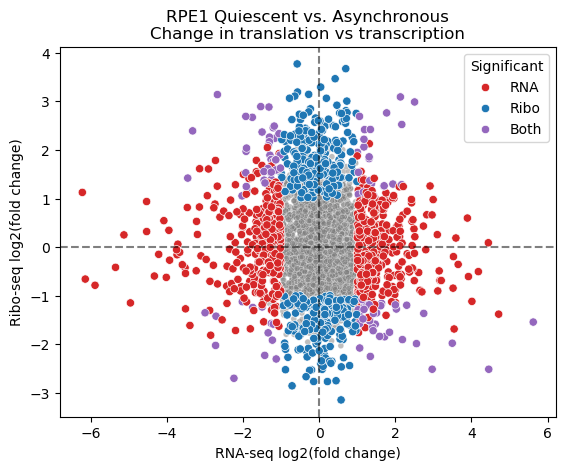

In [132]:
que_vs_async_rna = rpe1_pairwise_wald_rna_tests[('RPE1_Que', 'RPE1_Async')].merge(
    tis_metadata[['Gid', 'Symbol']].drop_duplicates(), left_index=True, right_on='Gid', how='left'
)
que_vs_async_tis = rpe1_pairwise_wald_tests[('RPE1_Que', 'RPE1_Async')].merge(
    tis_metadata, left_index=True, right_on='TIS', how='left'
)

que_vs_async_combined = merge_tis_and_rna_deseqs(que_vs_async_tis, que_vs_async_rna)
_, que_vs_async_filtered = plot_cross_scatter(que_vs_async_combined)
plt.title('RPE1 Quiescent vs. Asynchronous\nChange in translation vs transcription')
plt.xlabel('RNA-seq log2(fold change)')
plt.ylabel('Ribo-seq log2(fold change)')

Text(0, 0.5, 'Ribo-seq log2(fold change)')

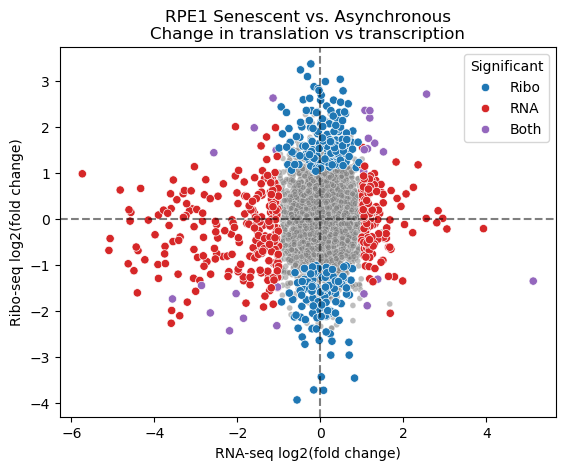

In [133]:
sen_vs_async_rna = rpe1_pairwise_wald_rna_tests[('RPE1_Sen', 'RPE1_Async')].merge(
    tis_metadata[['Gid', 'Symbol']].drop_duplicates(), left_index=True, right_on='Gid', how='left'
)
sen_vs_async_tis = rpe1_pairwise_wald_tests[('RPE1_Sen', 'RPE1_Async')].merge(
    tis_metadata, left_index=True, right_on='TIS', how='left'
)

sen_vs_async_combined = merge_tis_and_rna_deseqs(sen_vs_async_tis, sen_vs_async_rna)
_, sen_vs_async_filtered = plot_cross_scatter(sen_vs_async_combined)
plt.title('RPE1 Senescent vs. Asynchronous\nChange in translation vs transcription')
plt.xlabel('RNA-seq log2(fold change)')
plt.ylabel('Ribo-seq log2(fold change)')

<Axes: xlabel='Significant Assay', ylabel='Number of Genes'>

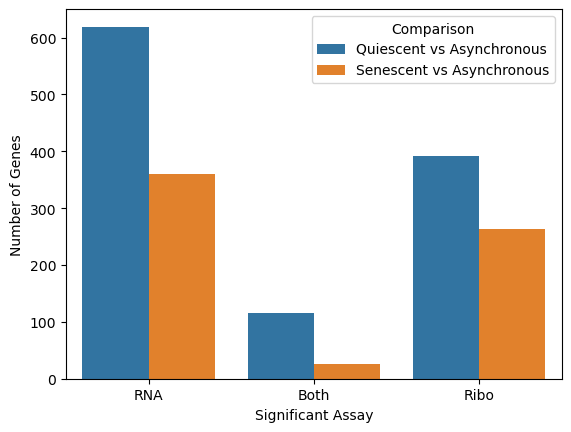

In [134]:
sns.barplot(
    pd.concat([
        que_vs_async_filtered.value_counts('Significant').drop('Neither').rename('Quiescent vs Asynchronous'),
        sen_vs_async_filtered.value_counts('Significant').drop('Neither').rename('Senescent vs Asynchronous'),
    ], axis=1).T.melt(ignore_index=False).reset_index(names=['Comparison']).rename({'Significant': 'Significant Assay', 'value': 'Number of Genes'}, axis=1),
    x='Significant Assay', y='Number of Genes', hue='Comparison', order=['RNA', 'Both', 'Ribo']
)

In [135]:
que_vs_async_filtered[que_vs_async_filtered['Significant'] == 'Both'].sort_values('Ribo_log2FoldChange', ascending=False).head(10)

,TIS,Ribo_log2FoldChange,Ribo_padj,Ribo_lfcSE,Symbol,SigRibo,RNA_log2FoldChange,RNA_padj,RNA_lfcSE,SigRNA,Significant
4262,ENST00000425080.1_234_chr1:225424075:-,3.138221,7.952402e-04,0.809226,LBR,True,-2.669584,4.162097e-38,0.201699,True,Both
7649,ENST00000379757.9_12_chr6:7910776:-,3.089878,2.034734e-05,0.633258,TXNDC5,True,2.136067,4.810344e-35,0.168425,True,Both
3293,ENST00000373212.6_99_chrX:81202200:+,2.985996,3.616398e-03,0.883811,SH3BGRL,True,2.508071,1.071754e-19,0.265993,True,Both
5949,ENST00000381967.9_47_chr4:37826732:+,2.890797,1.441394e-04,0.661458,PGM2,True,-1.531534,1.995817e-10,0.230827,True,Both
907,ENST00000267436.9_79_chr14:50312150:-,2.882448,6.235696e-03,0.906301,L2HGDH,True,-1.316524,2.321365e-03,0.396056,True,Both
4408,ENST00000336032.4_144_chr6:89080894:+,2.761307,4.589364e-03,0.838152,PNRC1,True,1.774392,7.254248e-12,0.248459,True,Both
4974,ENST00000506503.1_10_chr4:39182557:+,2.689875,1.925093e-02,0.982106,WDR19,True,1.061863,1.084268e-03,0.299592,True,Both
7385,ENST00000638160.1_0_chr1:241640254:-,2.689271,2.154052e-07,0.455442,CHML,True,-1.924009,4.781548e-11,0.280556,True,Both
3211,ENST00000252487.9_101_chr19:44891415:+,2.670464,1.684163e-03,0.733891,TOMM40,True,-1.752646,1.156379e-08,0.293700,True,Both
478,ENST00000316218.12_140_chr3:123067164:+,2.523096,2.122050e-02,0.935623,PDIA5,True,2.171911,1.177901e-13,0.281082,True,Both


In [286]:
sen_vs_async_filtered[sen_vs_async_filtered['Significant'] == 'Both'].sort_values('Ribo_log2FoldChange', ascending=False)

,TIS,Ribo_log2FoldChange,Ribo_padj,Ribo_lfcSE,Symbol,SigRibo,RNA_log2FoldChange,RNA_padj,RNA_lfcSE,SigRNA,Significant
4781,ENST00000423588.1_257_chr7:82443459:-,2.721853,0.009300,0.863124,CACNA2D1,True,2.559213,1.117401e-18,0.276006,True,Both
3948,ENST00000266742.9_305_chr12:96909759:+,2.636271,0.001252,0.691253,NEDD1,True,-1.140837,8.404961e-05,0.264558,True,Both
6306,ENST00000310325.10_120_chr11:66568486:-,2.367876,0.018473,0.815265,CTSF,True,1.074195,4.028770e-04,0.273202,True,Both
7060,ENST00000357166.11_394_chrX:129841945:-,2.362102,0.014684,0.789941,ZDHHC9,True,1.192122,8.708528e-07,0.226313,True,Both
4408,ENST00000336032.4_144_chr6:89080894:+,2.202848,0.038337,0.841853,PNRC1,True,1.190073,1.060238e-05,0.249555,True,Both
2211,ENST00000398514.7_372_chr5:147453587:-,1.988507,0.019061,0.687311,DPYSL3,True,-1.594013,1.230224e-10,0.234853,True,Both
4916,ENST00000542569.6_82_chr10:75150528:+,1.759644,0.026149,0.635165,SAMD8,True,1.156676,2.551378e-06,0.228679,True,Both
1536,ENST00000518176.5_122_chr8:133284311:-,1.653869,0.012991,0.545166,NDRG1,True,1.309210,2.353424e-04,0.321970,True,Both
4286,ENST00000272542.8_457_chr2:112646828:+,1.531785,0.000249,0.356225,SLC20A1,True,1.135507,3.762567e-10,0.171806,True,Both
6641,ENST00000319466.9_90_chr2:46909171:-,1.511763,0.001041,0.390480,MCFD2,True,1.057731,1.193431e-05,0.222961,True,Both


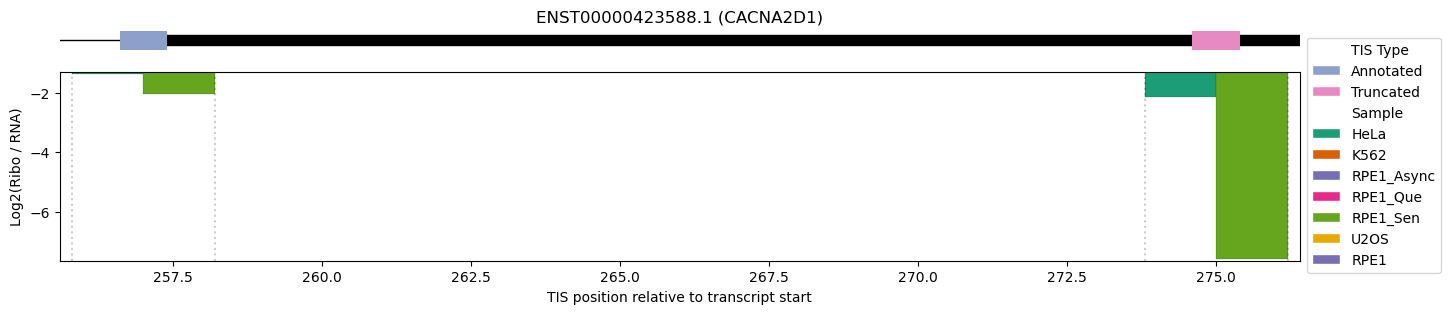

In [289]:
plot_tis_over_cell_lines(
    'ENST00000423588.1', tis_summary, masked_te_matrix,
    sample_palette=sample_palette, tis_type_palette=tistype_palette, position_width=2.4
)

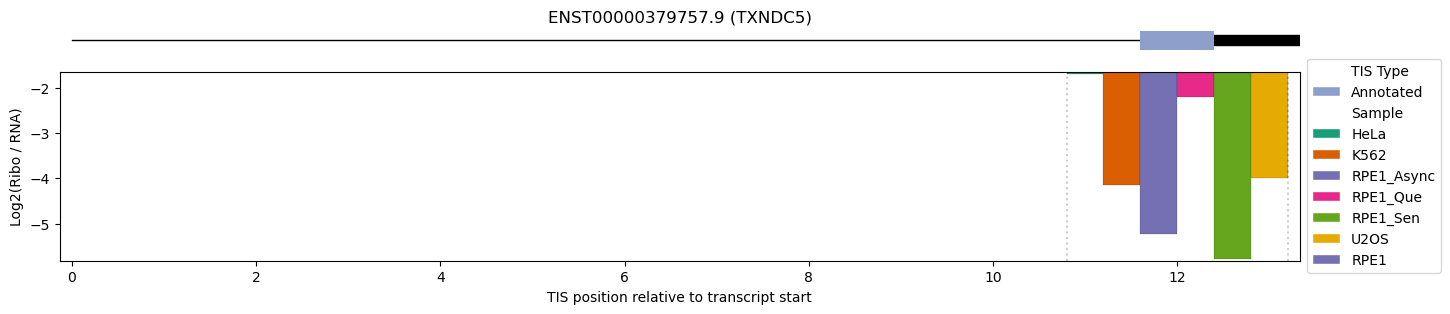

In [ ]:
plot_tis_over_cell_lines(
    'ENST00000379757.9', tis_summary, masked_te_matrix,
    sample_palette=sample_palette, tis_type_palette=tistype_palette, position_width=2.4
)

In [299]:
tis_summary

,TIS,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,LogTEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxLogRiboOverRNA,MaxLogTESample,MinLogRiboOverRNA,MinLogTESample,MaxLFCSamplePair,MaxLFCSamplePair.1,MinLFC,MinLFCSamplePair,MinDiffQValDirection,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff,LeaveOneOutLargestDeltaVariance,LeaveOneOutLargestDeltaRange,CandidateOutlier
0,ENST00000327044.7_16_chr1:959240:-,ENST00000327044.7,NOC2L,ENSG00000188976.12,protein_coding,ATG,16.0,Annotated,True,749.0,MAAAGSRKRRLAELTVDEFLASGFDSESESESENSPQAETREAREA...,6.0,0.569789,750,27.686890,K562,20,1.301993,HeLa,0.468332,RPE1_Sen,-1.672373,HeLa,2.065102,RPE1_Sen/HeLa,-0.847702,U2OS/RPE1_Sen,1.0,6.835541e-05,RPE1_Sen/HeLa,0.737417,1.000000,4.032940,-0.432752,-1.129217,HeLa
1,ENST00000487214.1_69_chr1:959240:-,ENST00000487214.1,NOC2L,ENSG00000188976.12,protein_coding,ATG,69.0,Other,False,254.0,MAAAGSRKRRLAELTVDEFLASGFDSESESESENSPQAETREAREA...,6.0,0.569789,750,27.686890,K562,20,1.301993,HeLa,0.468332,RPE1_Sen,-1.672373,HeLa,2.065102,RPE1_Sen/HeLa,-0.847702,U2OS/RPE1_Sen,1.0,6.835541e-05,RPE1_Sen/HeLa,0.737417,1.000000,4.032940,-0.432752,-1.129217,HeLa
2,ENST00000487214.1_90_chr1:959219:-,ENST00000487214.1,NOC2L,ENSG00000188976.12,protein_coding,AAG,90.0,Other,False,247.0,KRRLAELTVDEFLASGFDSESESESENSPQAETREAREAARSPDKP...,5.0,1.105162,124,2.374222,HeLa,0,0.000000,RPE1_Que,-0.584410,HeLa,-3.491402,K562,3.912286,U2OS/RPE1_Que,-5.044020,RPE1_Que/HeLa,-1.0,1.871483e-12,K562/HeLa,0.059515,1.000000,10.502444,-0.556217,-1.170804,K562
3,ENST00000624697.4_245_chr1:1013998:+,ENST00000624697.4,ISG15,ENSG00000187608.11,protein_coding,GTG,245.0,Extended,False,159.0,VKMLAGNEFQVSLSSSMSVSELKAQITQKIGVHAFQQRLAVHPSGV...,3.0,0.804389,26,0.549670,U2OS,0,0.000000,RPE1_Que,0.083161,HeLa,-1.700811,K562,2.041373,U2OS/RPE1_Que,-2.824292,RPE1_Que/HeLa,-1.0,7.331731e-03,K562/HeLa,0.618653,1.000000,1.926241,-0.537958,-1.053999,K562
4,ENST00000649529.1_50_chr1:1013546:+,ENST00000649529.1,ISG15,ENSG00000187608.11,protein_coding,GTG,50.0,Extended,True,174.0,VAHSPQPTAMGWDLTVKMLAGNEFQVSLSSSMSVSELKAQITQKIG...,1.0,NaN,94,1.799813,HeLa,0,0.000000,U2OS,1.833898,HeLa,1.833898,HeLa,-3.315588,RPE1_Que/HeLa,-6.726489,U2OS/HeLa,-1.0,6.462892e-07,K562/HeLa,0.001202,0.084831,3.269387,-inf,0.000000,HeLa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92815,ENST00000447601.7_189_chrX:154516043:-,ENST00000447601.7,FAM3A,ENSG00000071889.18,protein_coding,ATC,189.0,uORF,True,46.0,IFVPAPEAPVGKIVSQRVPEAPPGQAGFPRAFPRSPAWPGGWTNRS*,1.0,NaN,6,0.549670,U2OS,0,0.000000,HeLa,-1.610418,U2OS,-1.610418,U2OS,7.174129,U2OS/K562,4.222319,U2OS/RPE1_Que,1.0,1.388052e-04,U2OS/K562,0.012842,0.057460,1.966226,-inf,0.000000,U2OS
92816,ENST00000621967.4_199_chrX:154516043:-,ENST00000621967.4,FAM3A,ENSG00000071889.18,protein_coding,ATC,199.0,uORF,False,46.0,IFVPAPEAPVGKIVSQRVPEAPPGQAGFPRAFPRSPAWPGGWTNRS*,1.0,NaN,6,0.549670,U2OS,0,0.000000,HeLa,-1.610418,U2OS,-1.610418,U2OS,7.174129,U2OS/K562,4.222319,U2OS/RPE1_Que,1.0,1.388052e-04,U2OS/K562,0.012842,0.057460,1.966226,-inf,0.000000,U2OS
92817,ENST00000475423.1_132_chrX:154764900:+,ENST00000475423.1,DKC1,ENSG00000130826.20,protein_coding,ATT,132.0,Other,False,59.0,IILPKKHKKKKERKSLPEEDVAVSSNVFDFTLTKKKVYLNNKLKER...,1.0,NaN,31,2.839962,U2OS,0,0.000000,HeLa,-1.983104,U2OS,-1.983104,U2OS,8.949440,U2OS/K562,3.454969,U2OS/RPE1_Que,1.0,2.155141e-07,U2OS/K562,0.002395,0.116061,4.045870,-inf,0.000000,U2OS
92818,ENST00000369462.5_37_chrX:155071539:+,ENST00000369462.5,BRCC3,ENSG00000185515.16,protein_coding,GTG,37.0,Truncated,False,312.0,VVQAVQAVHLESDAFLVCLNHALSTEKEEVMGLCIGELNDDTRSDS...,1.0,NaN,6,0.549670,U2OS,0,0.000000,HeLa,-0.966092,U2OS,-0.966092,U2OS,5.594563,U2OS/K562,1.834478,U2OS/RPE1_Que,1.0,4.022869e-03,U2OS/K562,0.103077,0.791887,1.408627,-i

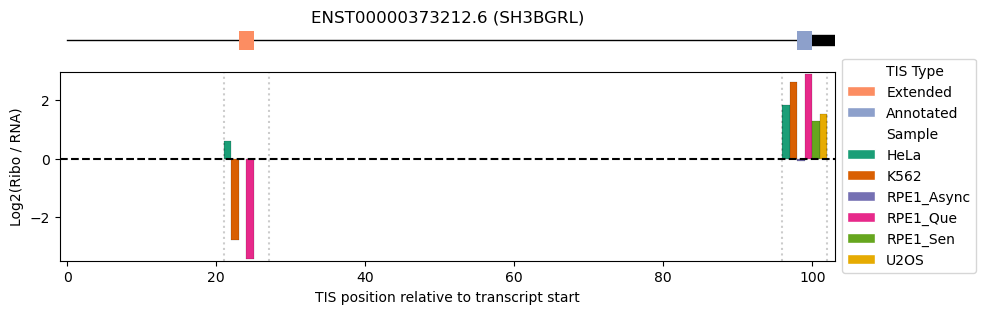

In [302]:
plot_tis_over_cell_lines(
    'ENST00000373212.6', tis_summary, masked_te_matrix,
    sample_palette=sample_palette, tis_type_palette=tistype_palette, position_width=6, figsize=(10, 3)
)

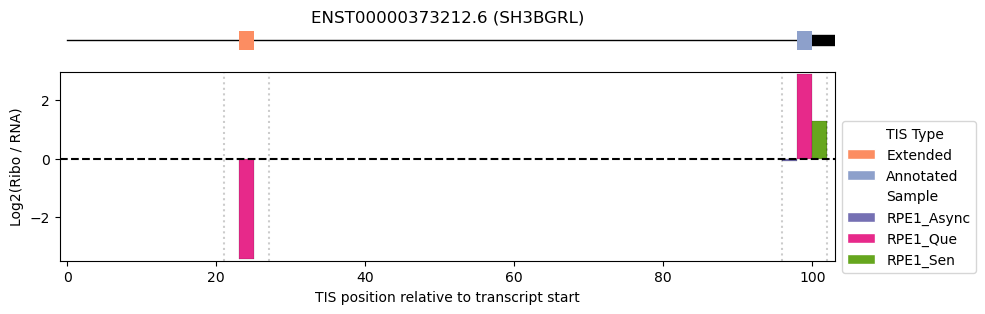

In [301]:
plot_tis_over_cell_lines(
    'ENST00000373212.6', tis_summary, masked_te_matrix.loc[:, ['RPE1_Async', 'RPE1_Que', 'RPE1_Sen']],
    sample_palette=sample_palette, tis_type_palette=tistype_palette, position_width=6, figsize=(10, 3)
)

In [136]:
def identify_common_sites(
    df1, df2, direction='both', top_n=None, assay='riboseq',
    min_effect=1, max_p=0.05, max_lfc_se=1,
    effect_column='log2FoldChange', p_column='padj'
):
    if assay.lower() in ['riboseq', 'ribo', 'tis']:
        merge_column = 'TIS'
        annot_columns = ['TIS', 'Symbol']
    elif assay.lower() in ['rna', 'rnaseq']:
        merge_column = 'Symbol'
        annot_columns = ['Symbol']

    sig1 = df1[
        (df1[effect_column].abs() > min_effect) & 
        (df1[p_column] < max_p) &
        (df1['lfcSE'] < max_lfc_se) 
    ].copy()

    sig2 = df2[
        (df2[effect_column].abs() > min_effect) & 
        (df2[p_column] < max_p) &
        (df2['lfcSE'] < max_lfc_se) 
    ].copy()

    sig1_ranked = sig1.sort_values(p_column)
    sig2_ranked = sig2.sort_values(p_column)

    if direction == 'both':
        sig1_ranked = sig1_ranked.head(n=top_n)
        sig2_ranked = sig1_ranked.head(n=top_n)
    elif direction in ['high', 'up']:
        sig1_ranked = sig1_ranked[sig1_ranked[effect_column] > 0].head(n=top_n)
        sig2_ranked = sig2_ranked[sig2_ranked[effect_column] > 0].head(n=top_n)
    elif direction in ['low', 'down']:
        sig1_ranked = sig1_ranked[sig1_ranked[effect_column] < 0].head(n=top_n)
        sig2_ranked = sig2_ranked[sig2_ranked[effect_column] < 0].head(n=top_n)

    combined_tis = list(set(sig1_ranked[merge_column].tolist()).intersection(set(sig2_ranked[merge_column].tolist())))
    annotated_combined_tis = pd.concat([
        sig1_ranked[sig1_ranked[merge_column].isin(combined_tis)][annot_columns],
        sig2_ranked[sig2_ranked[merge_column].isin(combined_tis)][annot_columns]
    ], axis=0).drop_duplicates(subset=['Symbol'])
    return annotated_combined_tis, sig1_ranked, sig2_ranked

def run_overrepresentation_analysis(query_genes, genesets):
    if isinstance(genesets, pd.DataFrame):
        genesets = genesets.groupby('Geneset').apply(lambda x: list(x['Gene'])).to_dict()
    ora = gp.enrich(
        gene_list=query_genes, 
        gene_sets=genesets, 
        outdir=None, 
        verbose=True)
    return ora.results.sort_values('Adjusted P-value')

In [158]:
def make_pretty_geneset_name(string, newline_spacing=3, title_case=True, preserve_collection=True):
    words = string.split('_')
    if preserve_collection:
        build_string = words[0] + ':'
        counter = 1
        remaining = words[1:]
    else:
        build_string = ''
        counter = 0
        remaining = words
    for w in remaining:
        if counter % newline_spacing == 0:
            build_string = build_string + '\n' + w.title()
        else:
            build_string = build_string + ' ' + w.title()
        counter += 1
    return build_string

def plot_geneset_stem(gsea_df_up, gsea_df_down, top_n=5, 
                      term_column='Term', size_column='Odds Ratio', p_column='Adjusted P-value', significance_threshold=0.05,
                      figsize=(12, 6), xlim=None, newline_spacing=3):
    up_df = gsea_df_up.sort_values(p_column).head(top_n).copy()
    up_df['p_transform'] = -np.log10(up_df[p_column])
    up_df['Geneset'] = up_df[term_column].apply(lambda x: make_pretty_geneset_name(x, newline_spacing=newline_spacing, title_case=True, preserve_collection=True))
    
    down_df = gsea_df_down.sort_values(p_column).head(top_n).copy()
    down_df['p_transform'] = -np.log10(down_df[p_column])
    down_df['Geneset'] = down_df[term_column].apply(lambda x: make_pretty_geneset_name(x, newline_spacing=newline_spacing, title_case=True, preserve_collection=True))

    fig, axs = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'wspace': 0})
    sns.barplot(down_df, x='p_transform', y='Geneset', color='tab:blue', ax=axs[0])
    sns.barplot(up_df, x='p_transform', y='Geneset', color='tab:red', ax=axs[1])

    if xlim is None:
        max_lim = max(axs[0].get_xlim()[1], axs[1].get_xlim()[1])
    else:
        max_lim = xlim
    axs[0].set_xlim(0, max_lim)
    axs[1].set_xlim(0, max_lim)

    axs[0].invert_xaxis()
    axs[0].set_xlabel('-log10 (FDR-adjusted p-value)')
    axs[1].set_xlabel('-log10 (FDR-adjusted p-value)')
    axs[1].yaxis.set_label_position('right')
    axs[1].yaxis.tick_right()

    axs[0].axvline(-np.log10(significance_threshold), color='black', linestyle='dashed', alpha=0.5)
    axs[1].axvline(-np.log10(significance_threshold), color='black', linestyle='dashed', alpha=0.5)

    return fig, axs

In [138]:
sen_tis_ora_up = run_overrepresentation_analysis(
    identify_common_sites(sen_vs_async_tis, que_vs_async_tis, direction='up')[1]['Symbol'],
    curated_genesets
)
sen_tis_ora_down = run_overrepresentation_analysis(
    identify_common_sites(sen_vs_async_tis, que_vs_async_tis, direction='down')[1]['Symbol'],
    curated_genesets
)

que_tis_ora_up = run_overrepresentation_analysis(
    identify_common_sites(sen_vs_async_tis, que_vs_async_tis, direction='up')[2]['Symbol'],
    curated_genesets
)
que_tis_ora_down = run_overrepresentation_analysis(
    identify_common_sites(sen_vs_async_tis, que_vs_async_tis, direction='down')[2]['Symbol'],
    curated_genesets
)

sen_rna_ora_up = run_overrepresentation_analysis(
    identify_common_sites(sen_vs_async_rna, que_vs_async_rna, assay='rna', direction='up')[1]['Symbol'],
    curated_genesets
)
sen_rna_ora_down = run_overrepresentation_analysis(
    identify_common_sites(sen_vs_async_rna, que_vs_async_rna, assay='rna', direction='down')[1]['Symbol'],
    curated_genesets
)

que_rna_ora_up = run_overrepresentation_analysis(
    identify_common_sites(sen_vs_async_rna, que_vs_async_rna, assay='rna', direction='up')[2]['Symbol'],
    curated_genesets
)
que_rna_ora_down = run_overrepresentation_analysis(
    identify_common_sites(sen_vs_async_rna, que_vs_async_rna, assay='rna', direction='down')[2]['Symbol'],
    curated_genesets
)

2026-03-23 12:17:03,848 [INFO] Input dict object named with gs_ind_0
2026-03-23 12:17:03,848 [INFO] Run: gs_ind_0
2026-03-23 12:17:09,484 [INFO]   Background is not set! Use all 19656 genes in gs_ind_0.
2026-03-23 12:17:11,386 [INFO] Done.
2026-03-23 12:17:13,002 [INFO] Input dict object named with gs_ind_0
2026-03-23 12:17:13,003 [INFO] Run: gs_ind_0
2026-03-23 12:17:18,638 [INFO]   Background is not set! Use all 19656 genes in gs_ind_0.
2026-03-23 12:17:20,691 [INFO] Done.
2026-03-23 12:17:22,289 [INFO] Input dict object named with gs_ind_0
2026-03-23 12:17:22,290 [INFO] Run: gs_ind_0
2026-03-23 12:17:27,886 [INFO]   Background is not set! Use all 19656 genes in gs_ind_0.
2026-03-23 12:17:30,104 [INFO] Done.
2026-03-23 12:17:31,738 [INFO] Input dict object named with gs_ind_0
2026-03-23 12:17:31,739 [INFO] Run: gs_ind_0
2026-03-23 12:17:37,343 [INFO]   Background is not set! Use all 19656 genes in gs_ind_0.
2026-03-23 12:17:40,022 [INFO] Done.
2026-03-23 12:17:41,624 [INFO] Input dic

Text(0.5, 0.98, 'RPE1 Quiescent vs. Asynchronous change in transcription (RNA-seq)')

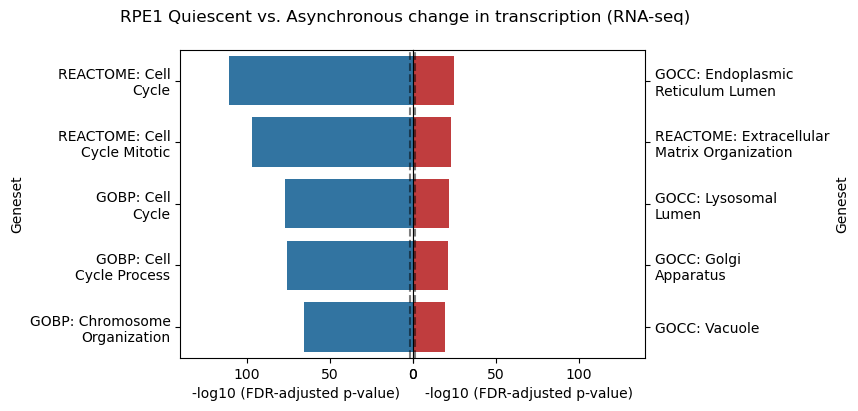

In [159]:
plot_geneset_stem(que_rna_ora_up, que_rna_ora_down, figsize=(6, 4), xlim=140, newline_spacing=2)
plt.suptitle('RPE1 Quiescent vs. Asynchronous change in transcription (RNA-seq)')

Text(0.5, 0.98, 'RPE1 Quiescent vs. Asynchronous change in translation (Ribo-seq / RNA-seq)')

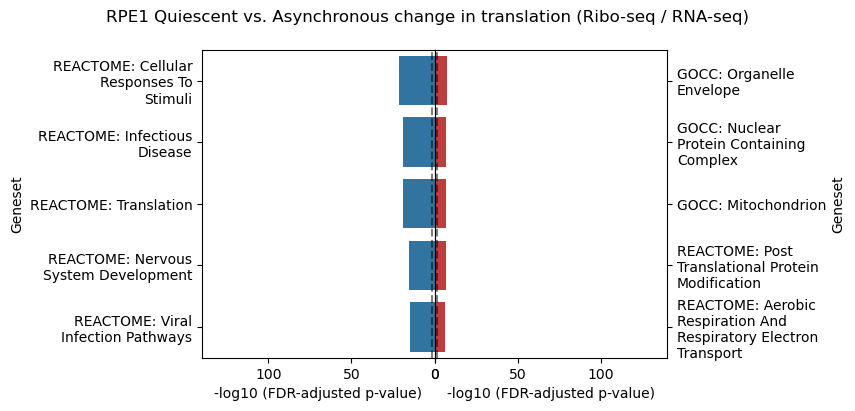

In [160]:
plot_geneset_stem(que_tis_ora_up, que_tis_ora_down, figsize=(6, 4), xlim=140, newline_spacing=2)
plt.suptitle('RPE1 Quiescent vs. Asynchronous change in translation (Ribo-seq / RNA-seq)')

Text(0.5, 0.98, 'RPE1 Senescent vs. Asynchronous change in transcription (RNA-seq)')

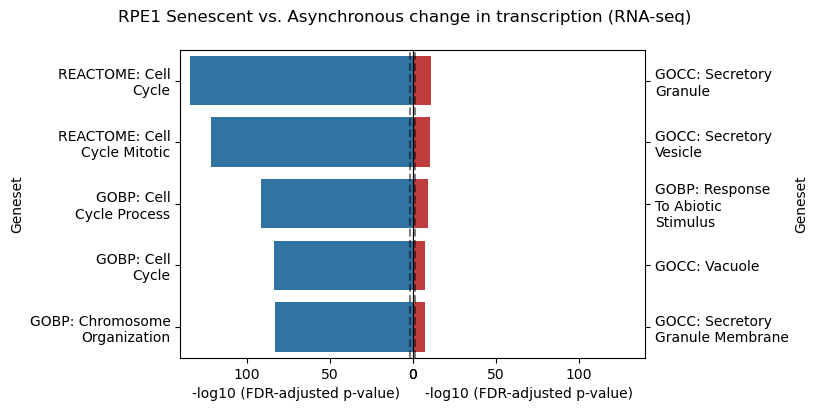

In [161]:
plot_geneset_stem(sen_rna_ora_up, sen_rna_ora_down, figsize=(6, 4), xlim=140, newline_spacing=2)
plt.suptitle('RPE1 Senescent vs. Asynchronous change in transcription (RNA-seq)')

Text(0.5, 0.98, 'RPE1 Senescent vs. Asynchronous change in translation (Ribo-seq / RNA-seq)')

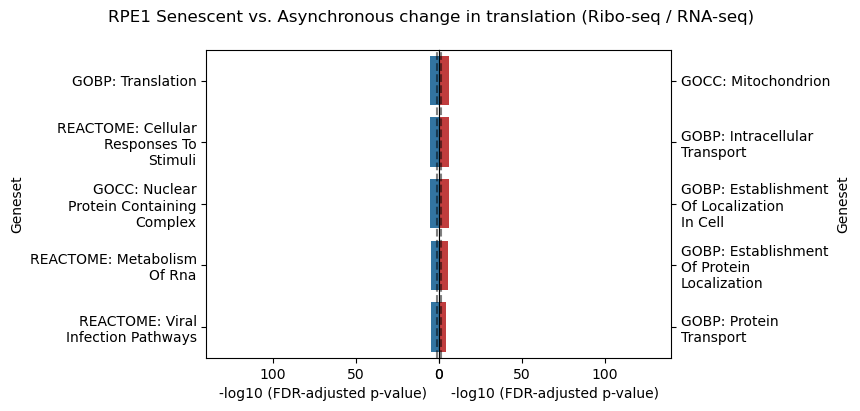

In [162]:
plot_geneset_stem(sen_tis_ora_up, sen_tis_ora_down, figsize=(6, 4), xlim=140, newline_spacing=2)
plt.suptitle('RPE1 Senescent vs. Asynchronous change in translation (Ribo-seq / RNA-seq)')